### PH464/564: Scientific Computing II
___

# Midterm Project
### Due: Mon, Nov 10th at 11:59pm Pacific
---

For this project we will use the [Gaia DR3 data release](https://gea.esac.esa.int/archive/) to explore the solar neighborhood. This is the same selection of data we've explored recently, which can be pulled from the Gaia data archive with the following query:

```sql
SELECT TOP 300000 phot_g_mean_mag+5*log10(parallax)-10 AS mg, bp_rp, parallax FROM gaiadr3.gaia_source
WHERE parallax_over_error > 10
AND parallax > 10
AND phot_g_mean_flux_over_error>50
AND phot_rp_mean_flux_over_error>20
AND phot_bp_mean_flux_over_error>20
AND phot_bp_rp_excess_factor < 1.3+0.06*power(phot_bp_mean_mag-phot_rp_mean_mag,2)
AND phot_bp_rp_excess_factor > 1.0+0.015*power(phot_bp_mean_mag-phot_rp_mean_mag,2)
AND visibility_periods_used>8
AND astrometric_chi2_al/(astrometric_n_good_obs_al-5)<1.44*greatest(1,exp(-0.4*(phot_g_mean_mag-19.5)))
```

The data is also in the `data/` directory of this repository.

Using a subset of this data, we're going to focus on constructing models and inferring the parameters of those models using `NumPyro`.

## Data Down-Selection

To avoid lengthy run times we'll focus on only the nearby data.  Select out the objects with parallax > 40 milliarcseconds.


# Part I

For this part we'll remove (crudely) the white dwarf population (the dim secondary population of stars).  To do this we'll use a simple linear boundary to divide the population:

```python
x1, y1 = 0, 8
x2, y2 = 3, 16.5
m_div = (y2 - y1)/(x2 - x1)
b_div = y1 - m_div * x1
```

where we'll be focusing on the objects with $M_G < m_\mathrm{div} (BP-RP) + b_\mathrm{div}$.

1. Construct a `NumPyro` model that models the population as a line, assuming $M_G$ to be distributed normally about this line with a standard deviation to be inferred from the data.  Perform an MCMC.

    A. Discuss the differences between the prior distributions you choose for your model parameters and the marginal (i.e., one-dimensional) posterior distributions estimated with your MCMC.  Did you choose suitably uninformed priors?

    B. Plot the models corresponding to 50 randomly chosen posterior samples from your MCMC.  Discuss the quality of the fit, and in particular the role that the standard deviation parameter is playing in this fit.

2. Construct a new model that models the relation between $(BP-RP)$ and $M_G$ quadratically.  Carefully choose priors; be sure to explore choices for locations and scales that are appropriate for the new parameters.  Run an MCMC.

    A. Discuss the differences between the prior distributions you choose for your model parameters and the marginal (i.e., one-dimensional) posterior distributions estimated with your MCMC.  Did you choose suitably uninformed priors?

    B. Plot the model corresponding to 50 randomly chosen posterior samples from your MCMC.  Discuss the quality of the fit.

    C. **Graduate students:** Use your posterior estimates to predict the distribution we would expect for $M_G$ values of main sequence stars with color $(BP-RP) = 6$.

3. **Graduate students:** Explore higher order polynomials a bit.  How does the (qualitative) quality of the fit behave?

## Problem 1

In [1]:
from numpy import genfromtxt

import jax
from jax import random
import jax.numpy as jnp

import numpyro
import numpyro.distributions as dist
from numpyro import infer
numpyro.set_host_device_count(1) # let's use 2 cores!

import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az

import pandas as pd

In [2]:
import matplotlib
matplotlib.rcParams['font.family'] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"
font = {'size' : 12}
plt.rc('font', **font)

In [3]:
df = pd.read_csv('../../hub_data_share/gaiadr3_solar_neighborhood.csv')
df

,mg,bp_rp,parallax
0,10.390250,2.731872,10.000008
1,8.608481,2.025819,10.000029
2,4.267759,0.880858,10.000032
3,10.506658,2.649735,10.000066
4,12.077941,2.940875,10.000111
...,...,...,...
227624,11.758283,2.834036,336.026602
227625,9.521769,2.215609,392.752945
227626,14.129570,4.184836,415.179416
227627,11.883816,2.833697,546.975940


In [4]:
nearby_sel = df.parallax > 40.
nearby_df = df[nearby_sel]

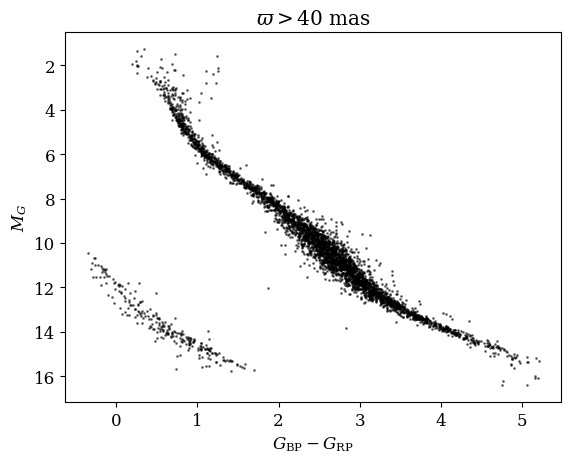

In [5]:
plt.scatter(nearby_df.bp_rp, nearby_df.mg, s=1, alpha=0.5, color='k')
plt.gca().invert_yaxis()
plt.title(r'$\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

ylow, yhigh = plt.ylim()
plt.show()

In [6]:
wd_color = (-0.4, 1.8)
wd_mg = (10, 16.5)

wd_sel = ((nearby_df.bp_rp > wd_color[0]) & (nearby_df.bp_rp < wd_color[1]) &
    (nearby_df.mg > wd_mg[0]) & (nearby_df.mg < wd_mg[1]))

main_df = nearby_df[~wd_sel]

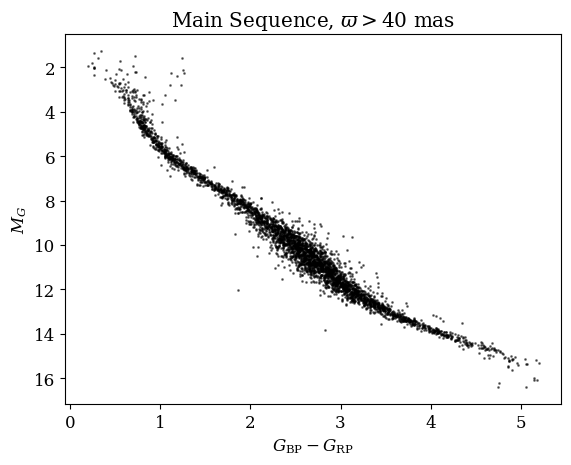

In [7]:
plt.scatter(main_df.bp_rp, main_df.mg, s=1, alpha=0.5, color='k')
plt.gca().invert_yaxis()
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

plt.show()

In [8]:
x = jnp.array(main_df['bp_rp'])
y = jnp.array(main_df['mg'])

In [8]:
def linear_model(x=None, y=None, σ=None):
    # priors
    m = numpyro.sample('m', dist.Uniform(0, 5))
    b = numpyro.sample('b', dist.Uniform(0, 500))
    σ = numpyro.sample('σ', dist.HalfNormal(5))

    # define the mean of the normal distribution
    μ = m * x + b

    # Likelihood
    with numpyro.plate("data", len(x)):
        numpyro.sample("y", dist.Normal(μ, σ), obs=y)

In [10]:
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)

kernel = infer.NUTS(linear_model)
num_samples = 5000
mcmc = infer.MCMC(
    kernel,
    num_chains=2,
    num_warmup=1000,
    num_samples=num_samples)
mcmc.run(rng_key_,
         x=x,
         y=y)
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         b      2.58      0.03      2.58      2.54      2.63   3813.58      1.00
         m      2.94      0.01      2.94      2.92      2.95   3785.13      1.00
         σ      0.57      0.01      0.57      0.56      0.58   4842.09      1.00

Number of divergences: 0


In [11]:
samples = mcmc.get_samples()
samples

{'b': Array([2.5783582, 2.609351 , 2.6207159, ..., 2.5744715, 2.5877566,
        2.5648985], dtype=float32),
 'm': Array([2.9403358, 2.9255238, 2.9236624, ..., 2.9309332, 2.9351041,
        2.942926 ], dtype=float32),
 'σ': Array([0.5802017 , 0.5722329 , 0.57335794, ..., 0.5673038 , 0.5695531 ,
        0.5684729 ], dtype=float32)}

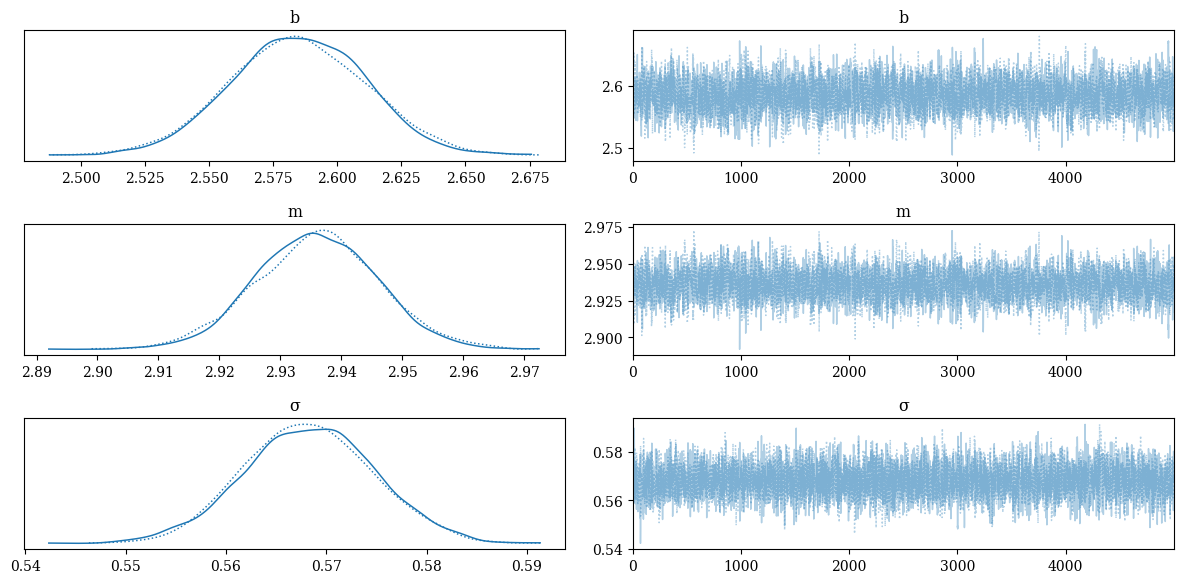

In [12]:
az.plot_trace(mcmc);
plt.tight_layout()
plt.show()

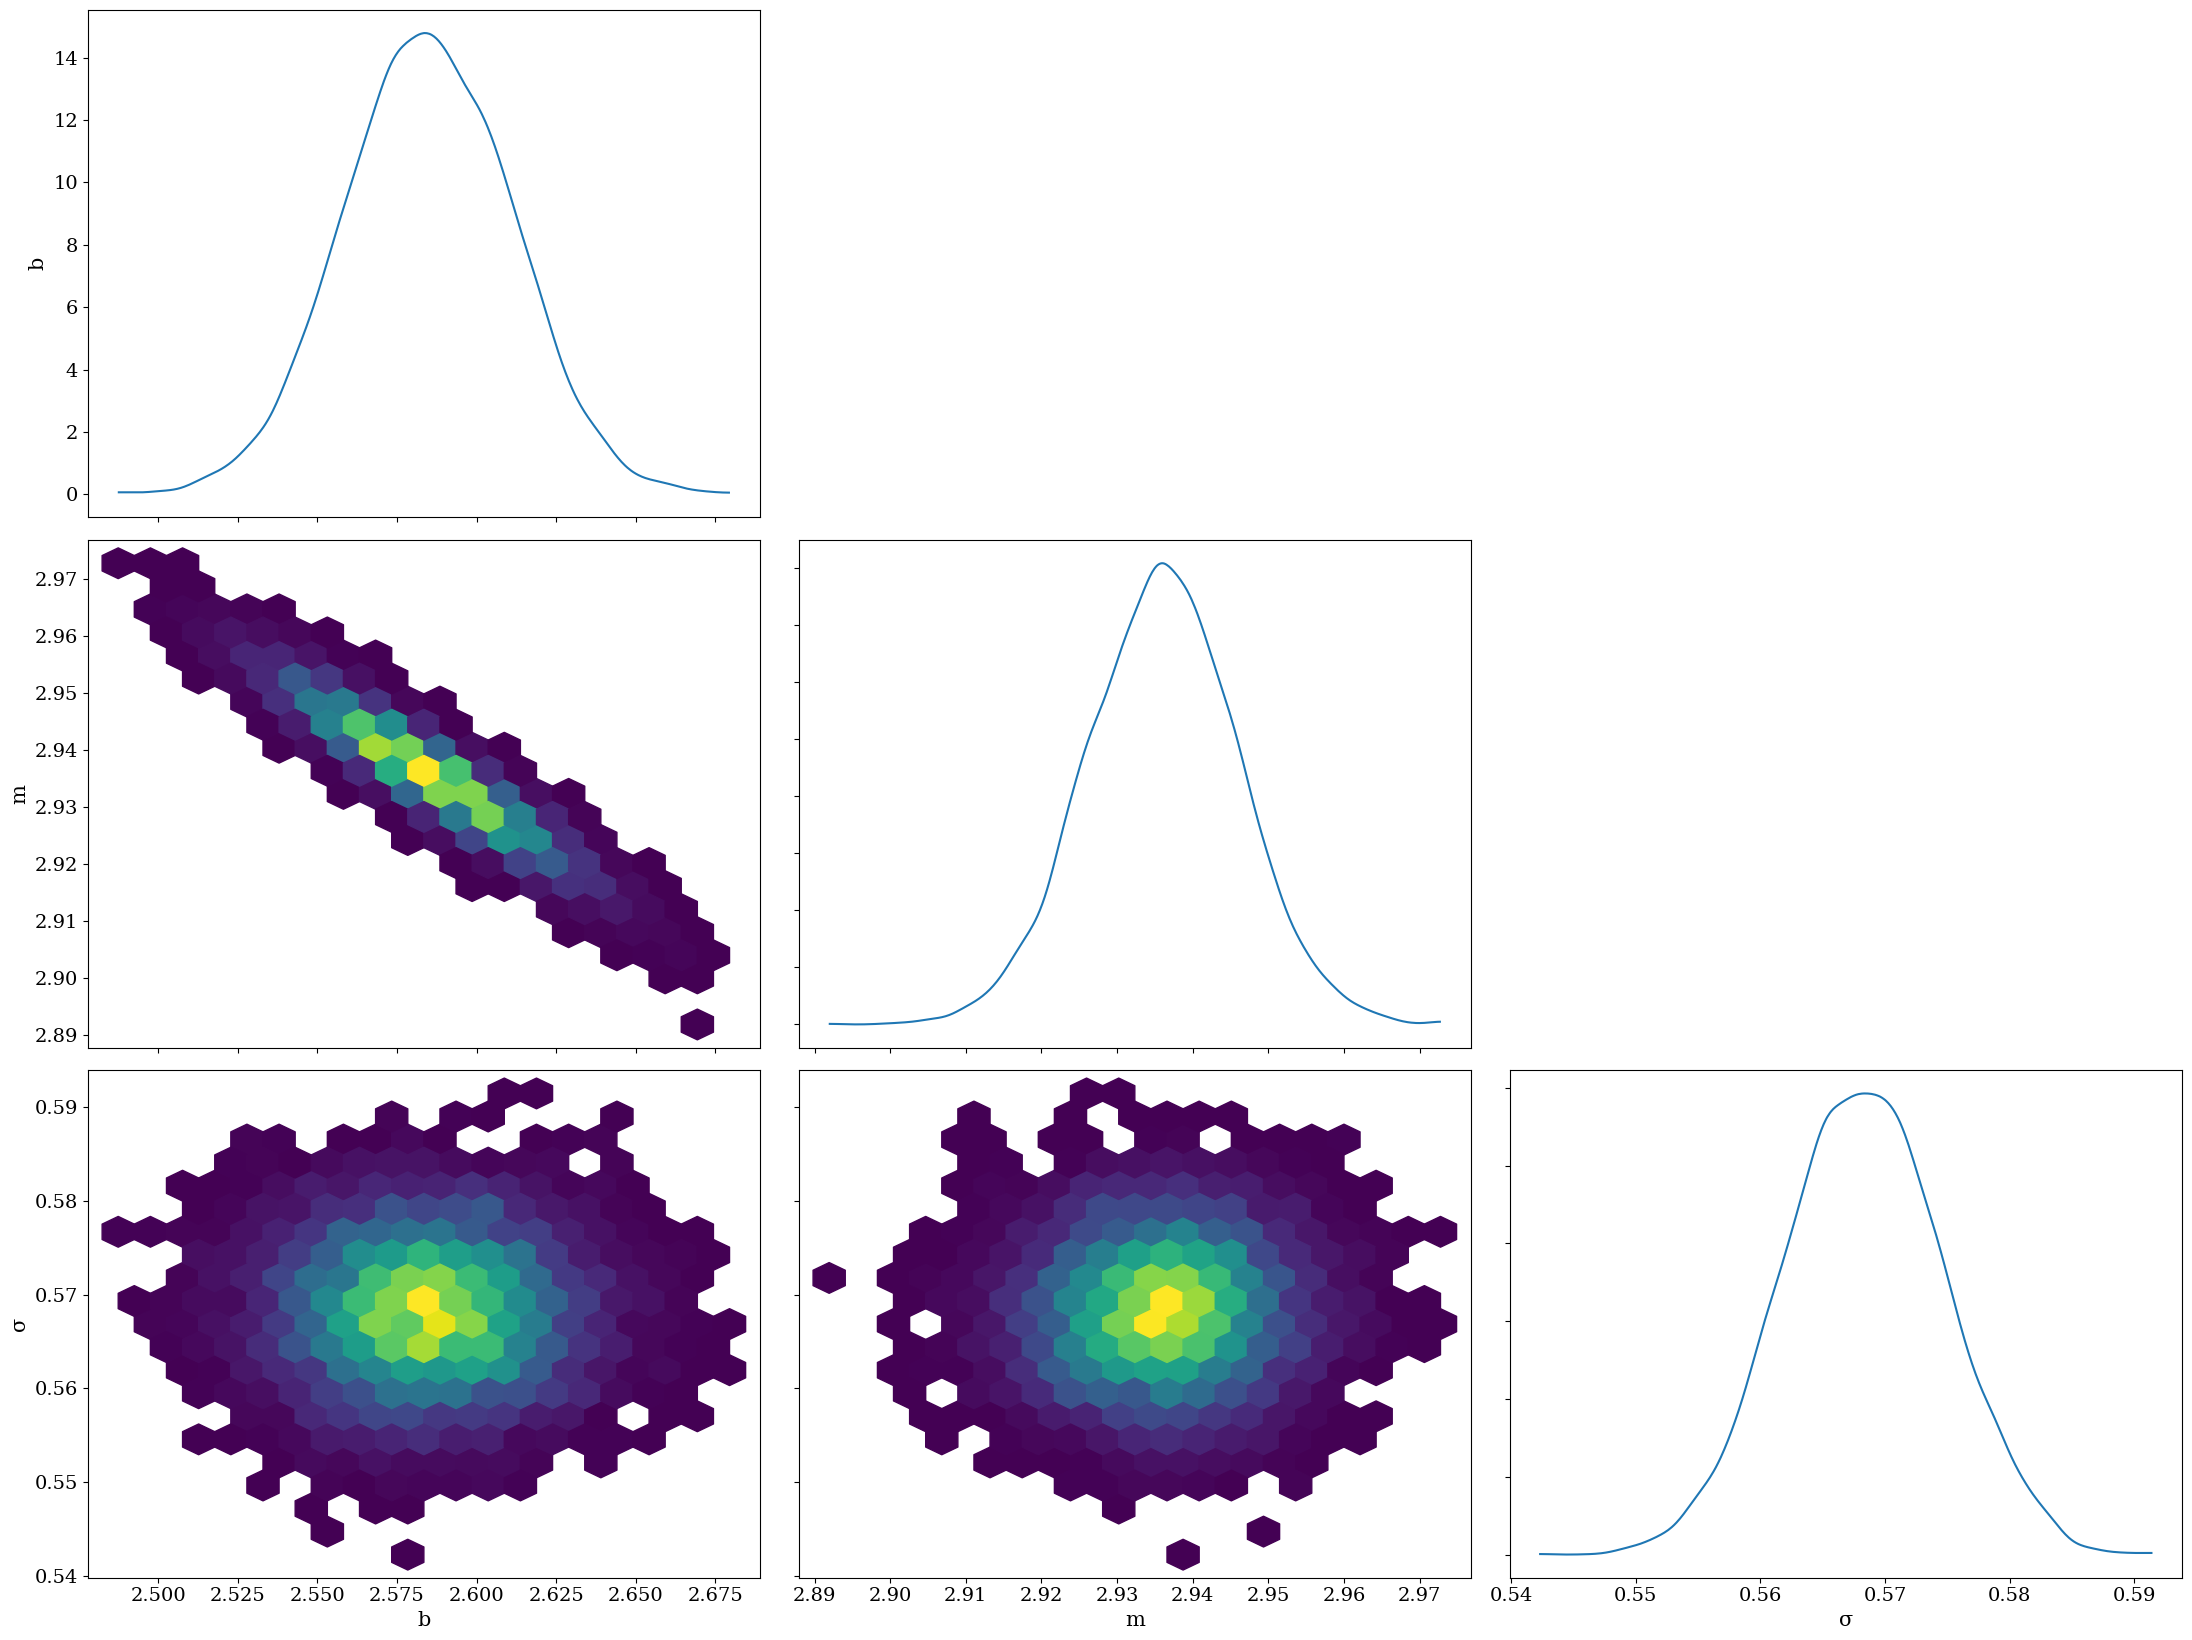

In [13]:
az.plot_pair(mcmc,marginals=True, kind='hexbin')
plt.tight_layout()
plt.show()

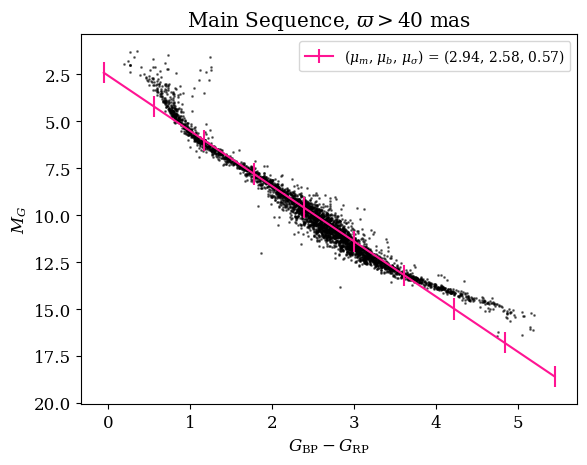

In [14]:
mean_m = jnp.mean(samples['m']).item()
mean_b = jnp.mean(samples['b']).item()
mean_sigmg = jnp.mean(samples['σ']).item()

plt.scatter(main_df.bp_rp, main_df.mg, s=1, alpha=0.5, color='k')
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

xlow, xhigh = plt.xlim()
testx = jnp.linspace(xlow, xhigh, 10)
mu = mean_m * testx + mean_b

plt.errorbar(testx, mu, yerr=mean_sigmg, color='deeppink',  
             label=fr'($\mu_m$, $\mu_b$, $\mu_{{\sigma}}$) = (${round(mean_m,2)}$, ${round(mean_b,2)}$, ${round(mean_sigmg,2)}$)')
    
plt.legend(fontsize='small')
plt.gca().invert_yaxis()
plt.show()

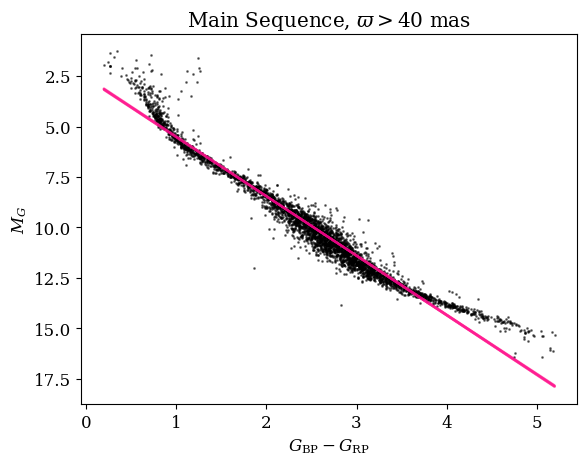

In [15]:
plt.scatter(main_df.bp_rp, main_df.mg, s=1, alpha=0.5, color='k')
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

xlow, xhigh = plt.xlim()
testx = jnp.linspace(xlow, xhigh, 100)

for i in random.choice(rng_key, num_samples, (50,)):
    mu = samples['m'][i] * x + samples['b'][i]
    plt.plot(x, mu, color='deeppink', alpha=0.05);
    
plt.gca().invert_yaxis()
plt.show()

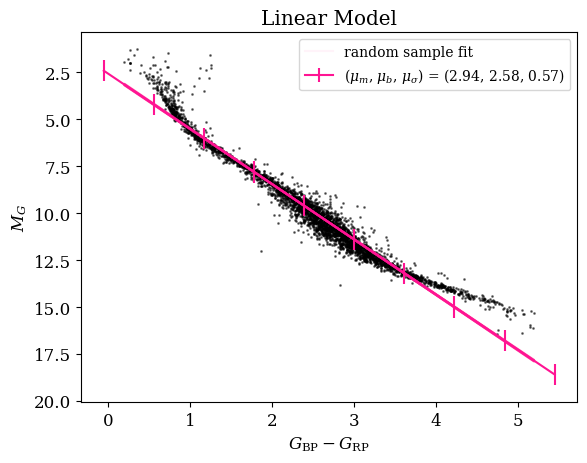

In [16]:
plt.scatter(main_df.bp_rp, main_df.mg, s=1, alpha=0.5, color='k')
plt.title(r'Linear Model')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

xlow, xhigh = plt.xlim()
testx = jnp.linspace(xlow, xhigh, 100)

label = "random sample fit"
for i in random.choice(rng_key, num_samples, (50,)):
    mu = samples['m'][i] * x + samples['b'][i]
    plt.plot(x, mu, color='deeppink', alpha=0.05, label=label);
    label = None
    
testx = jnp.linspace(xlow, xhigh, 10)
mu = mean_m * testx + mean_b

plt.errorbar(testx, mu, yerr=mean_sigmg, color='deeppink',  
             label=fr'($\mu_m$, $\mu_b$, $\mu_{{\sigma}}$) = (${round(mean_m,2)}$, ${round(mean_b,2)}$, ${round(mean_sigmg,2)}$)')
    
plt.legend(fontsize='small')
plt.gca().invert_yaxis()
plt.show()

## Problem 2

In [17]:
def quad_model(x=None, y=None, σ=None):
    # priors
    a = numpyro.sample('a', dist.Normal(scale=100))
    b = numpyro.sample('b', dist.Normal(scale=100))
    c = numpyro.sample('c', dist.Normal(scale=100))

    σ = numpyro.sample('σ', dist.HalfNormal(scale=5))

    # Define the mean of the normal likelihood
    μ = numpyro.deterministic("μ",  a*x**2 + b*x + c)

    # Likelihood (sampling distribution) of observations
    with numpyro.plate("data", len(x)):
        obs = numpyro.sample('y', dist.Normal(loc=μ, scale=σ), obs=y)

In [18]:
# Generate a starting key, which we'll split for later operations.
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)

kernel = infer.NUTS(quad_model)
num_samples = 5000
mcmc = infer.MCMC(
    kernel,
    num_chains=2,
    num_warmup=1000,
    num_samples=num_samples)
mcmc.run(rng_key_,
         x=x,
         y=y)
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         a     -0.30      0.01     -0.30     -0.31     -0.29   2529.36      1.00
         b      4.40      0.03      4.40      4.35      4.46   2430.86      1.00
         c      1.06      0.04      1.06      1.00      1.12   2639.86      1.00
         σ      0.45      0.01      0.45      0.44      0.46   3794.01      1.00

Number of divergences: 0


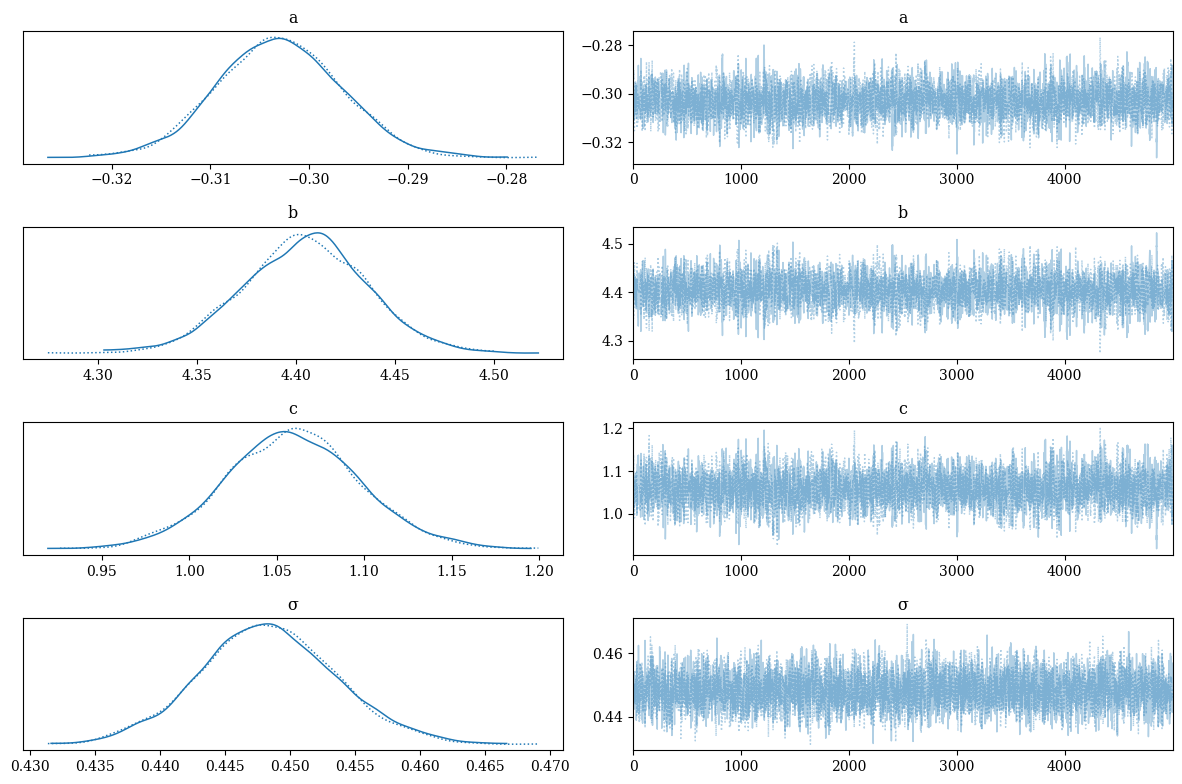

In [19]:
az.plot_trace(mcmc, var_names=["~μ"]);
plt.tight_layout()

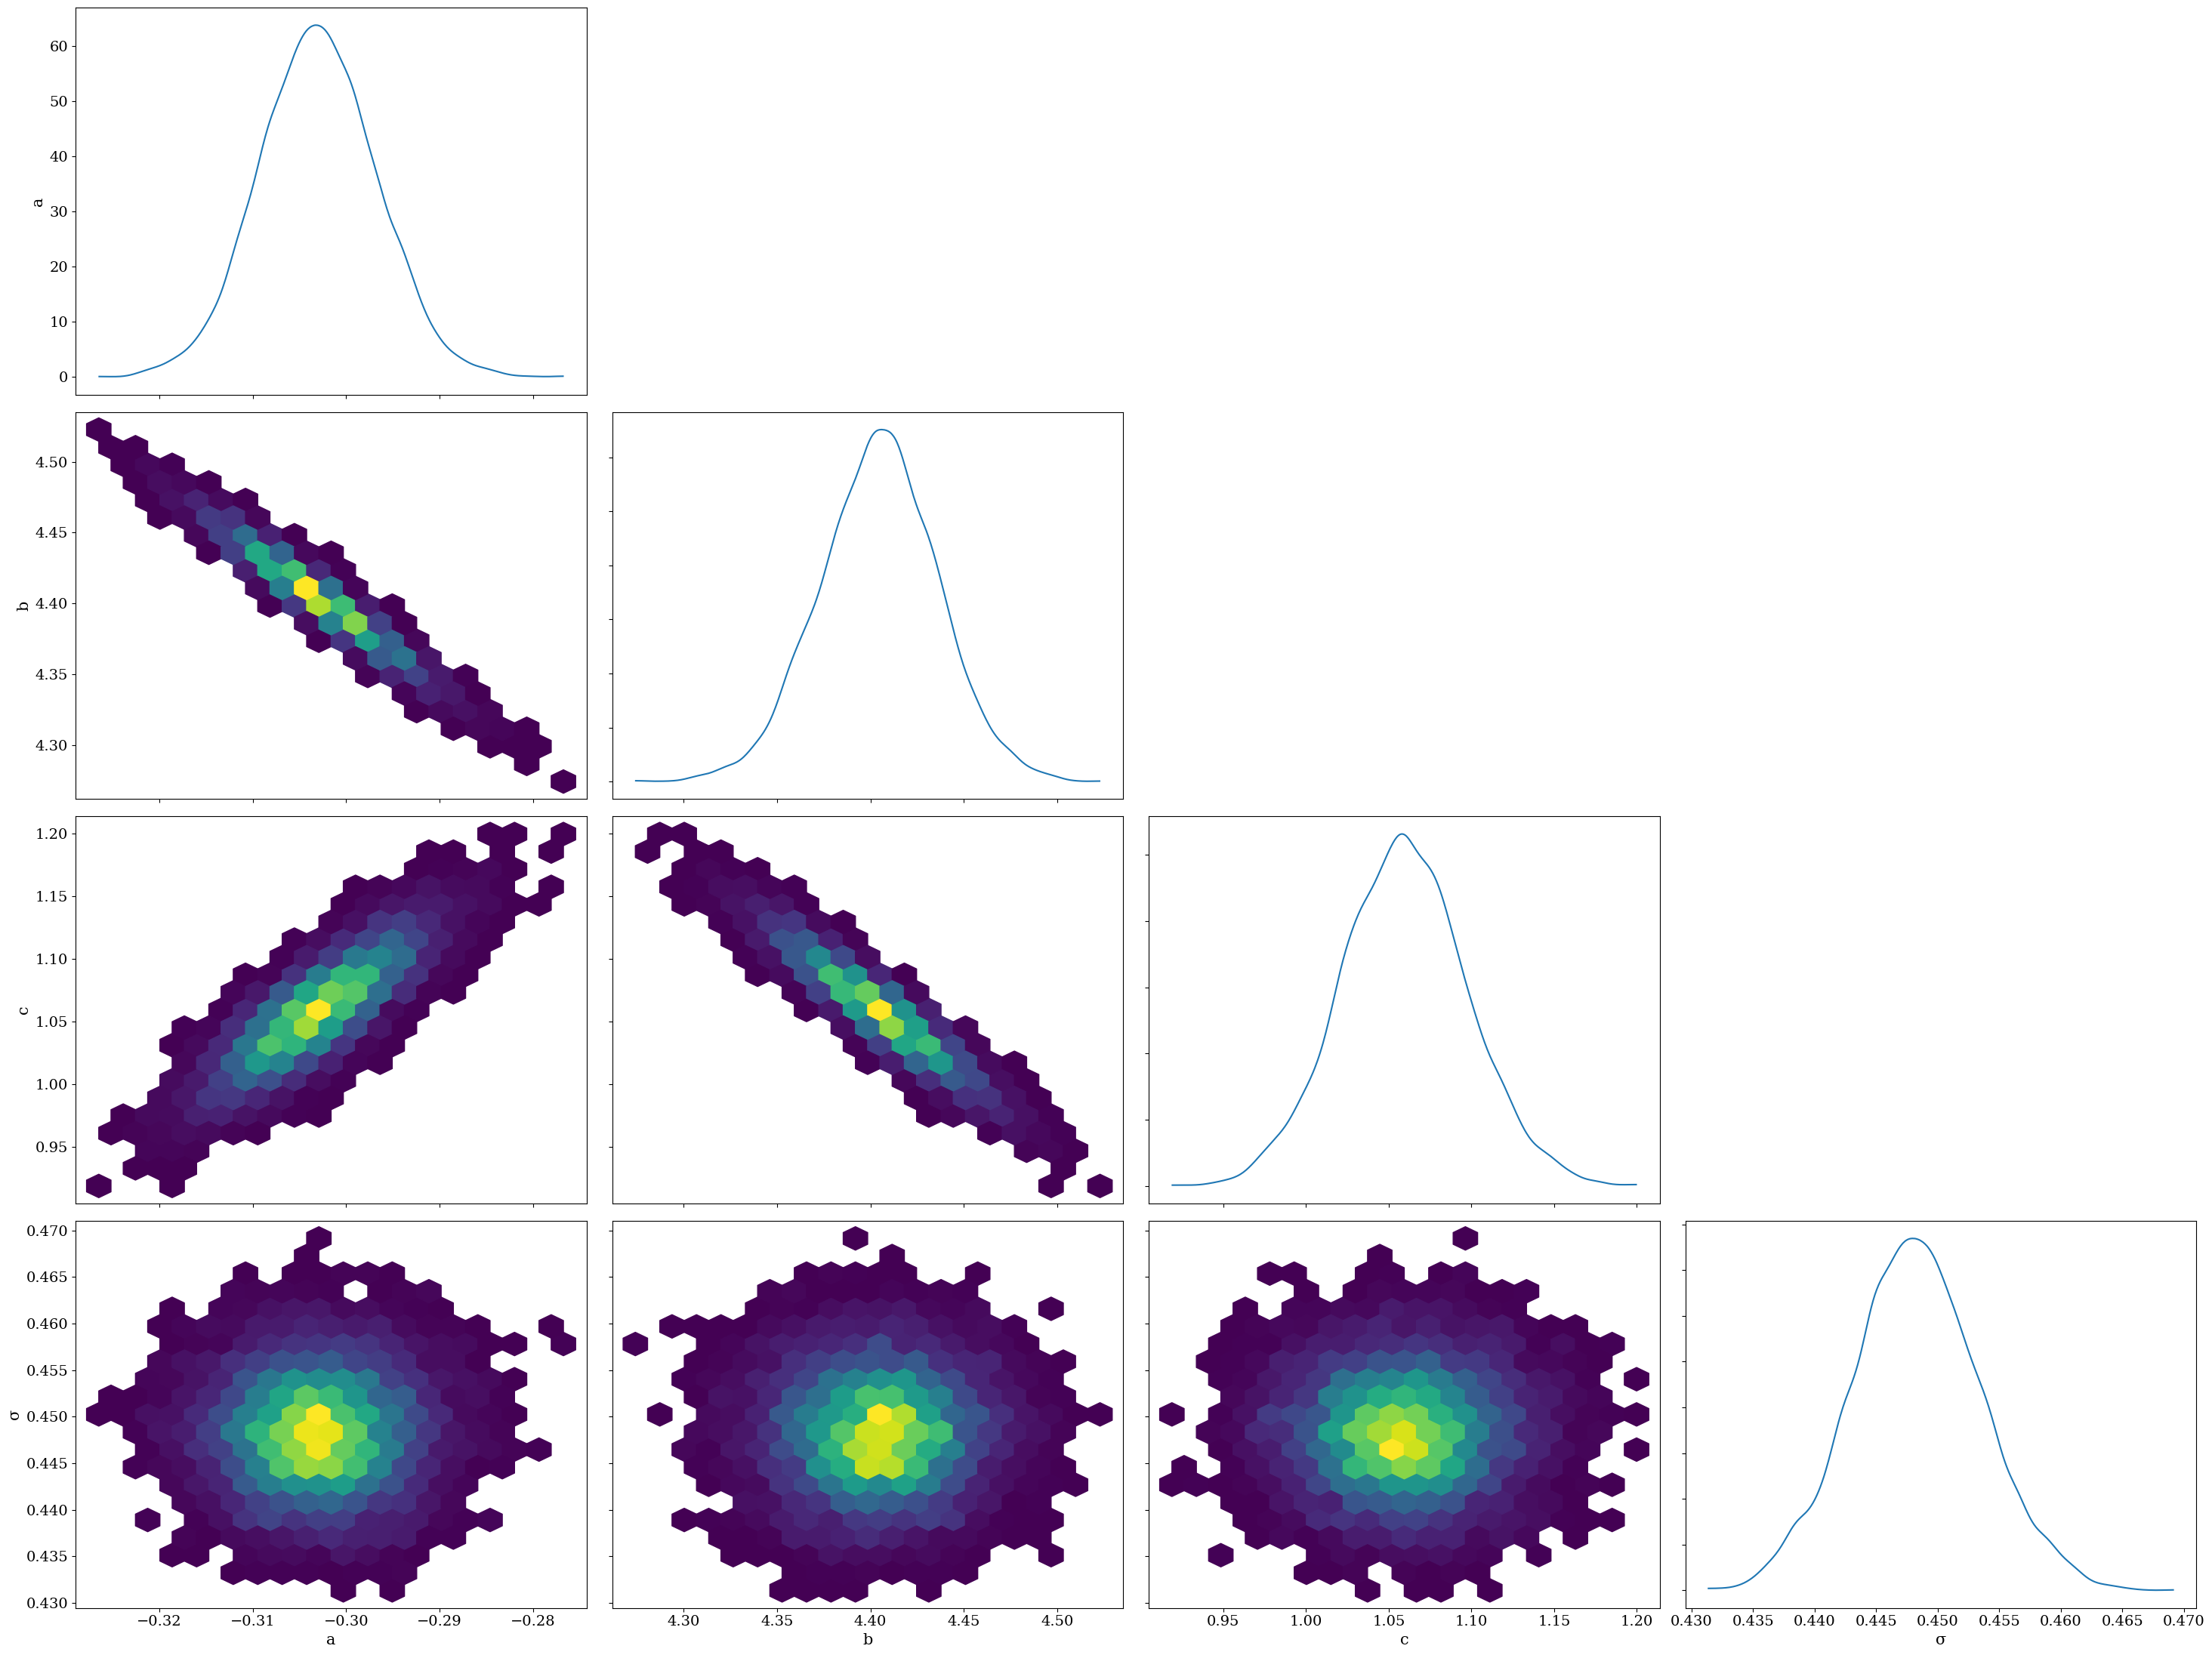

In [20]:
az.plot_pair(mcmc,marginals=True, kind='hexbin', var_names=["~μ"])
plt.tight_layout()
plt.show()

In [21]:
samples = mcmc.get_samples()

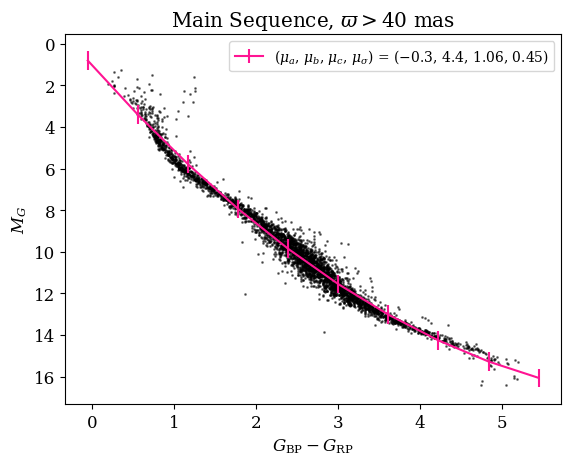

In [22]:
mean_a = jnp.mean(samples['a']).item()
mean_b = jnp.mean(samples['b']).item()
mean_c = jnp.mean(samples['c']).item()
mean_sigma = jnp.mean(samples['σ']).item()

plt.scatter(main_df.bp_rp, main_df.mg, s=1, alpha=0.5, color='k')
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

xlow, xhigh = plt.xlim()
testx = jnp.linspace(xlow, xhigh, 10)
mu = mean_a * testx**2 + mean_b * testx + mean_c

plt.errorbar(testx, mu, yerr=mean_sigma, color='deeppink',  
             label=fr'($\mu_a$, $\mu_b$, $\mu_c$, $\mu_{{\sigma}}$) = (${round(mean_a,2)}$, ${round(mean_b,2)}$, ${round(mean_c,2)}$, ${round(mean_sigma,2)}$)')
    
plt.legend(fontsize='small')
plt.gca().invert_yaxis()
plt.show()

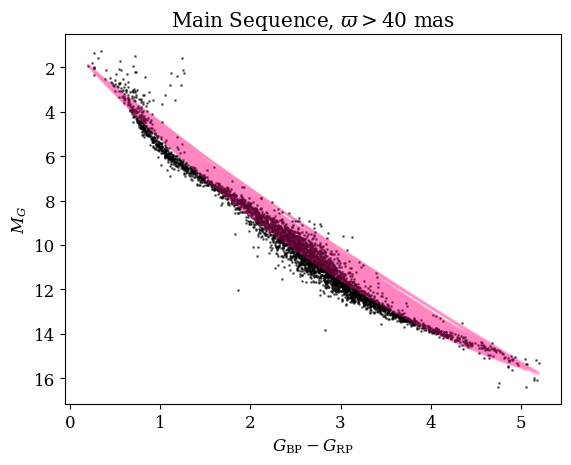

In [23]:
plt.scatter(main_df.bp_rp, main_df.mg, s=1, alpha=0.5, color='k')
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

xlow, xhigh = plt.xlim()
testx = jnp.linspace(xlow, xhigh, 100)

for i in random.choice(rng_key, num_samples, (50,)):
    mu = samples['a'][i] * x**2 + samples['b'][i] * x + samples['c'][i]
    plt.plot(x, mu, color='deeppink', alpha=0.01);
    
plt.gca().invert_yaxis()
plt.show()

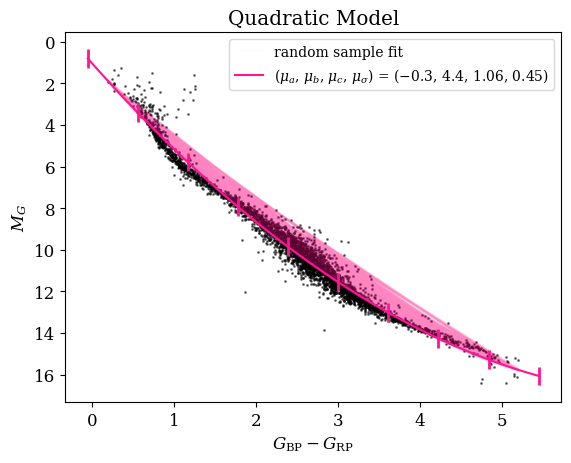

In [24]:
plt.scatter(main_df.bp_rp, main_df.mg, s=1, alpha=0.5, color='k')
plt.title(r'Quadratic Model')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

xlow, xhigh = plt.xlim()
testx = jnp.linspace(xlow, xhigh, 100)

label = "random sample fit"
for i in random.choice(rng_key, num_samples, (50,)):
    mu = samples['a'][i] * x**2 + samples['b'][i] * x + samples['c'][i]
    plt.plot(x, mu, color='deeppink', alpha=0.01, label=label);
    label = None
    
mu = mean_a * testx**2 + mean_b * testx + mean_c
plt.plot(testx, mu, color='deeppink', 
         label=fr'($\mu_a$, $\mu_b$, $\mu_c$, $\mu_{{\sigma}}$) = (${round(mean_a,2)}$, ${round(mean_b,2)}$, ${round(mean_c,2)}$, ${round(mean_sigma,2)}$)')

testx = jnp.linspace(xlow, xhigh, 10)
mu = mean_a * testx**2 + mean_b * testx + mean_c

plt.errorbar(testx, mu, yerr=mean_sigma, color='deeppink', linewidth=0, elinewidth=2)
    
plt.legend(fontsize='small')
plt.gca().invert_yaxis()
plt.show()

In [61]:
post_pred_samples = infer.Predictive(quad_model, samples)(
    random.PRNGKey(1), x=jnp.array([6.0]), y=None
)
post_pred_y = post_pred_samples['y'].reshape(-1)
post_pred_y.shape

(10000,)

In [64]:
mean_pt = jnp.mean(post_pred_y).item()
median_pt = jnp.median(post_pred_y).item()
std_pt = jnp.std(post_pred_y).item()

print(f"Posterior predictive at x=6: mean = {mean_pt:.2f}, median = {median_pt:.2f}, std = {std_pt:.2f}")

Posterior predictive at x=6: mean = 16.58, median = 16.58, std = 0.45


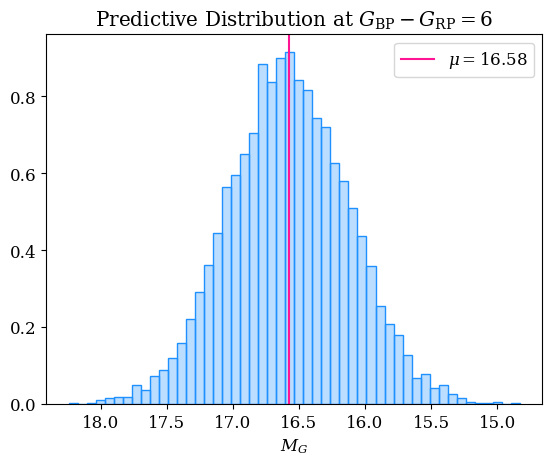

In [69]:
plt.hist(jnp.array(post_pred_y), bins=50, density=True, facecolor=(0.118, 0.565, 1, 0.3), edgecolor=(0.118, 0.565, 1, 1))

plt.axvline(mean_pt, color='deeppink', lw=1.5, label=fr'$\mu={mean_pt:.2f}$')

plt.xlabel('$M_G$')
plt.title(r'Predictive Distribution at $G_\mathrm{BP} - G_\mathrm{RP} =6$')

plt.gca().invert_xaxis()
plt.legend()
plt.show()

## Problem 3

### Cubic Model

In [25]:
def cubic_model(x=None, y=None, σ=None):
    # priors
    a = numpyro.sample('a', dist.Normal(scale=100))
    b = numpyro.sample('b', dist.Normal(scale=100))
    c = numpyro.sample('c', dist.Normal(scale=100))
    d = numpyro.sample('d', dist.Normal(scale=100))

    σ = numpyro.sample('σ', dist.HalfNormal(scale=5))

    # Define the mean of the normal likelihood
    μ = numpyro.deterministic("μ",  a*x**3 + b*x**2 + c*x + d)

    # Likelihood (sampling distribution) of observations
    with numpyro.plate("data", len(x)):
        obs = numpyro.sample('y', dist.Normal(loc=μ, scale=σ), obs=y)

In [26]:
# Generate a starting key, which we'll split for later operations.
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)

kernel = infer.NUTS(cubic_model)
num_samples = 5000
mcmc = infer.MCMC(
    kernel,
    num_chains=2,
    num_warmup=1000,
    num_samples=num_samples)
mcmc.run(rng_key_,
         x=x,
         y=y)
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         a     -0.02      0.01     -0.02     -0.03     -0.01   2002.98      1.00
         b     -0.17      0.04     -0.17     -0.25     -0.11   1917.80      1.00
         c      4.11      0.10      4.11      3.93      4.28   1875.50      1.00
         d      1.24      0.07      1.24      1.12      1.36   1958.13      1.00
         σ      0.45      0.01      0.45      0.44      0.46   3377.66      1.00

Number of divergences: 0


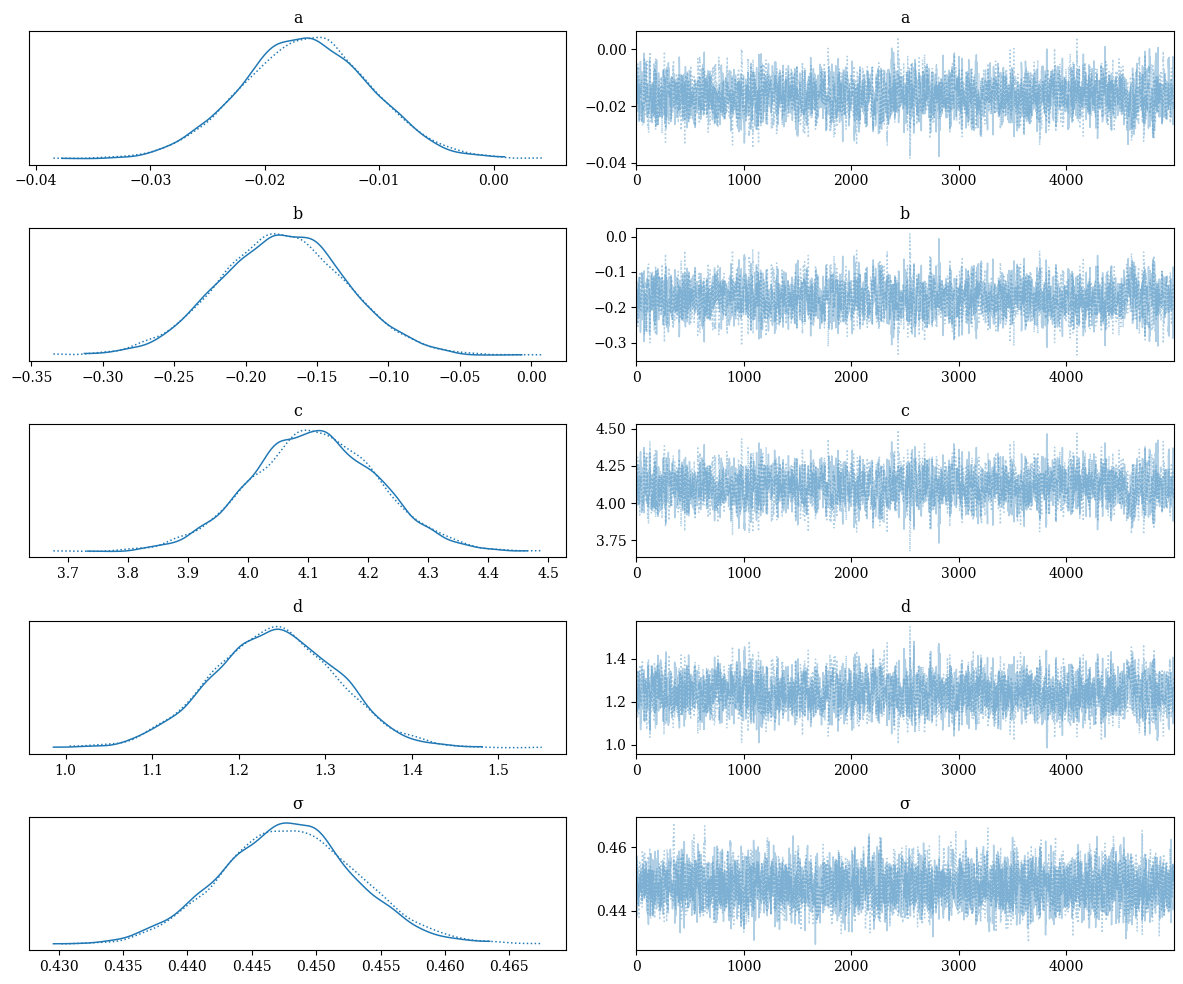

In [27]:
az.plot_trace(mcmc, var_names=["~μ"]);
plt.tight_layout()

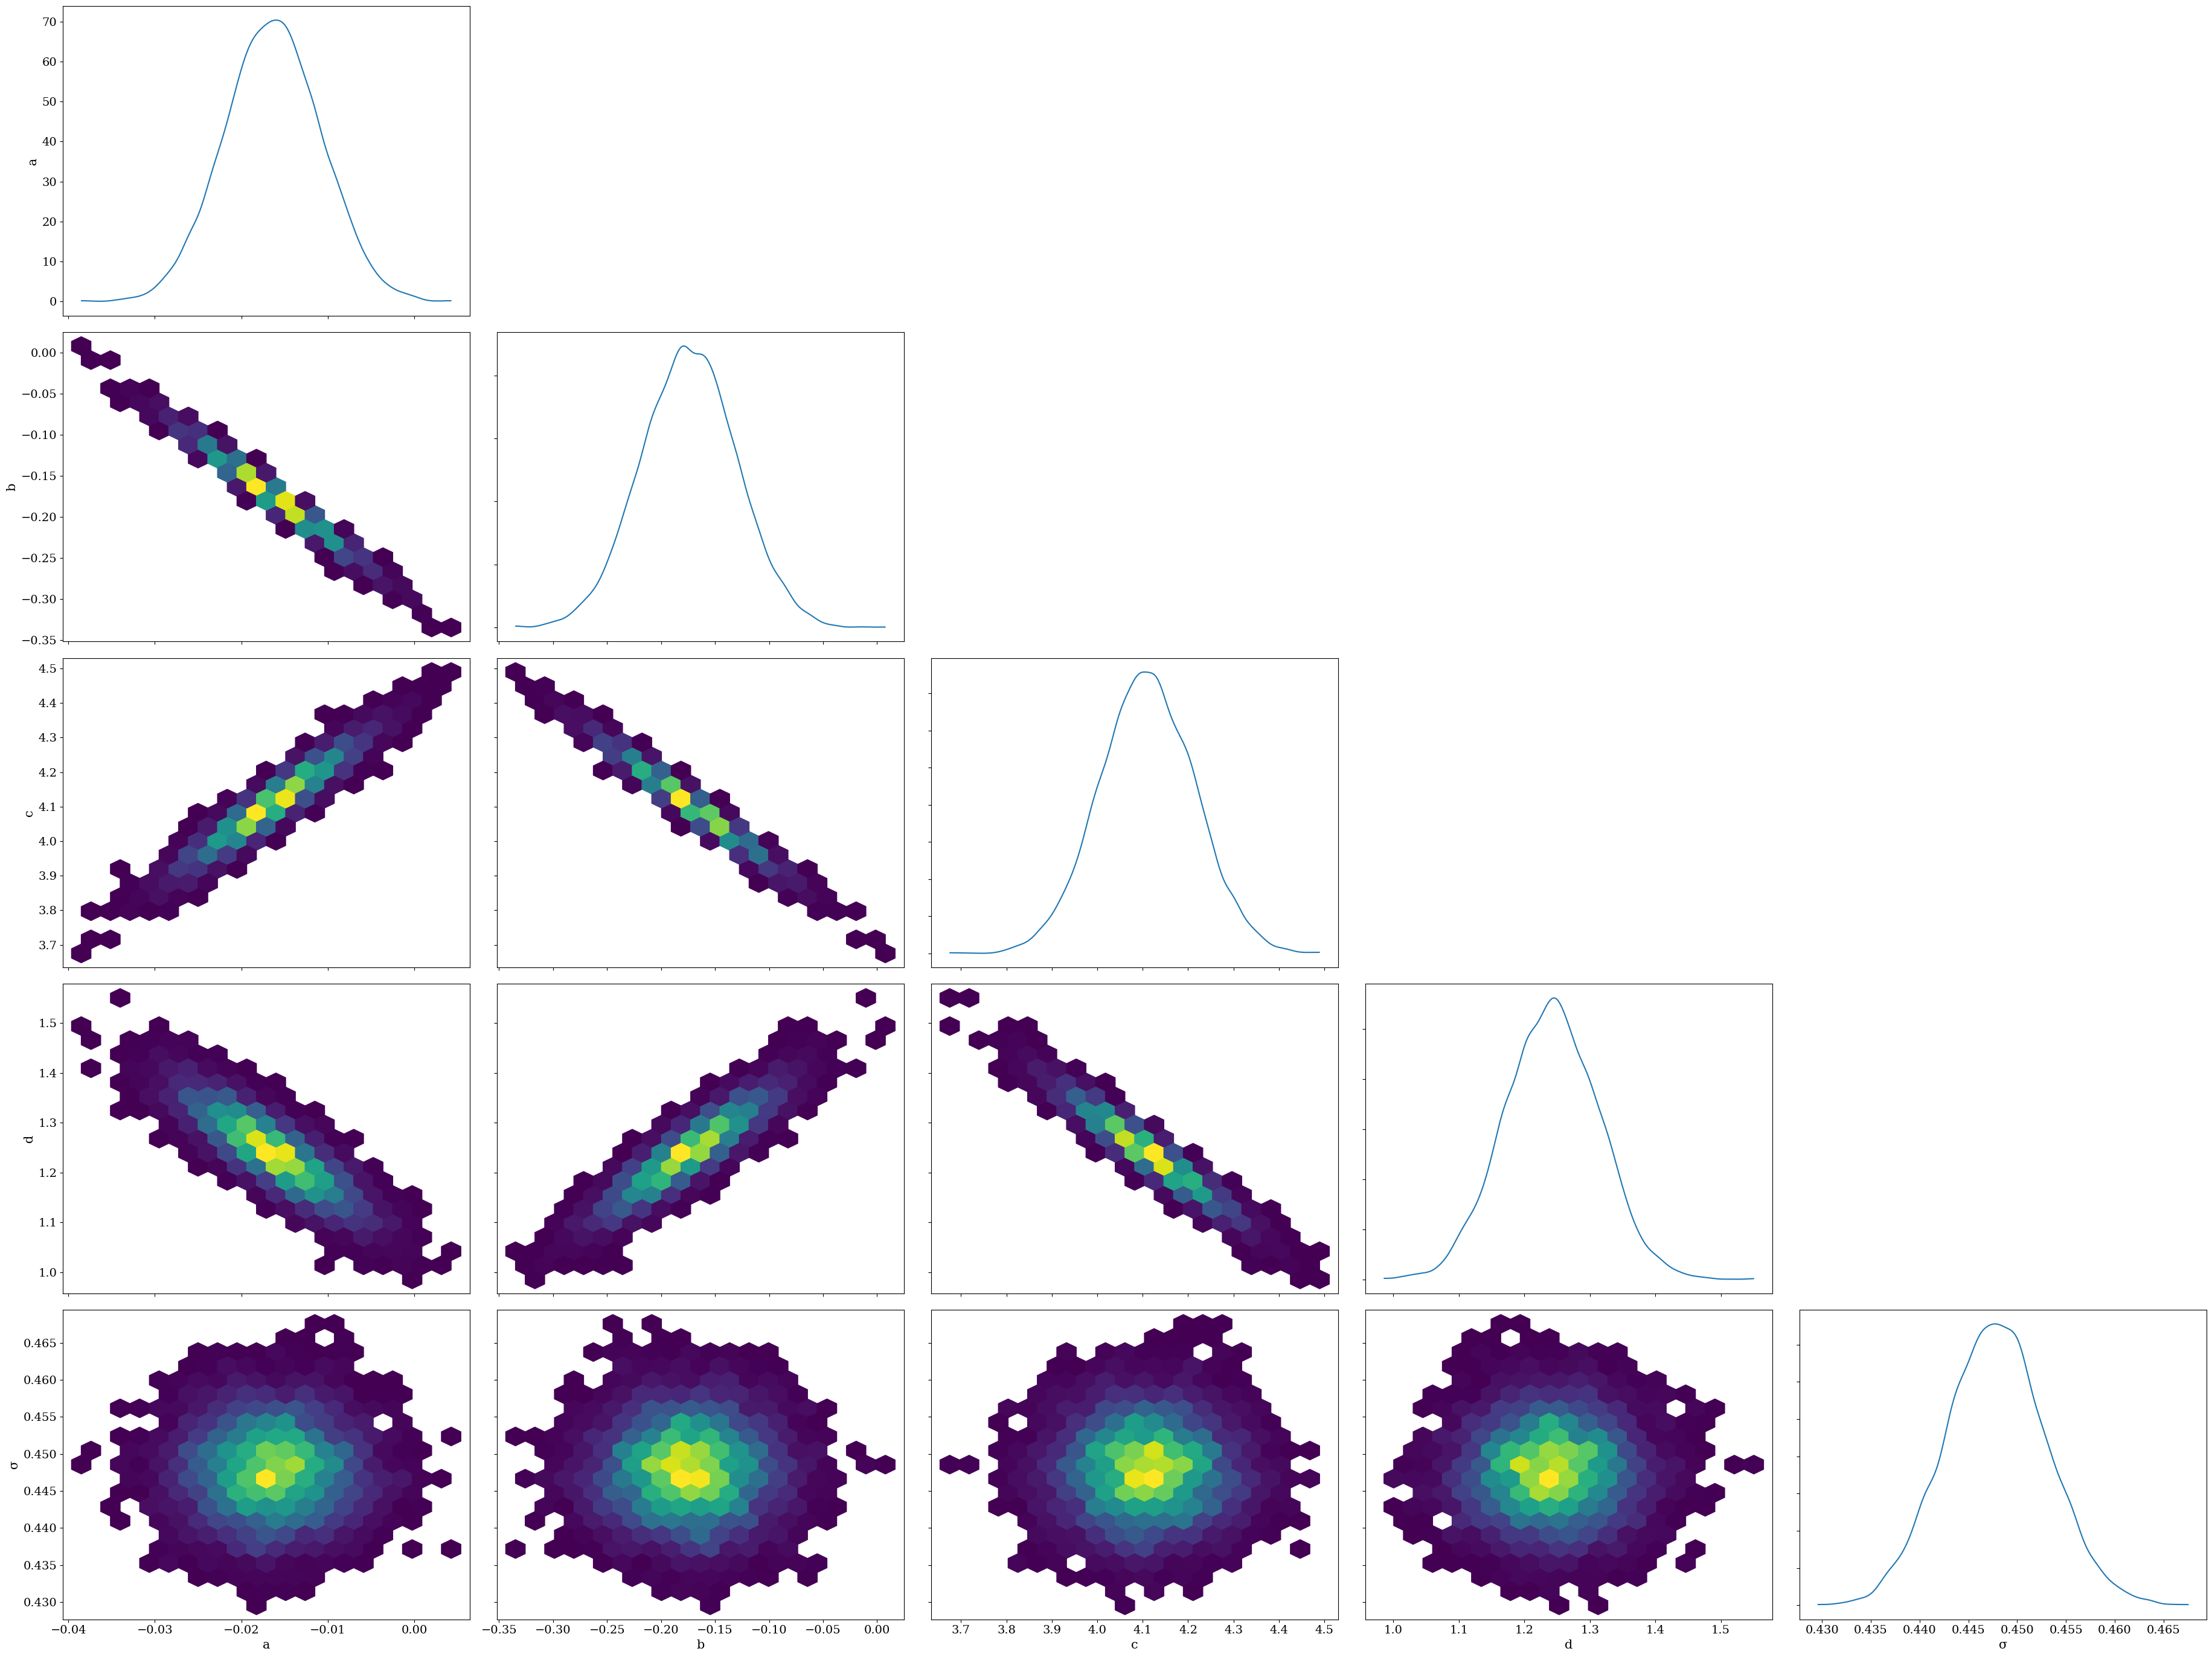

In [28]:
az.plot_pair(mcmc,marginals=True, kind='hexbin', var_names=["~μ"])
plt.tight_layout()
plt.show()

In [29]:
samples = mcmc.get_samples()

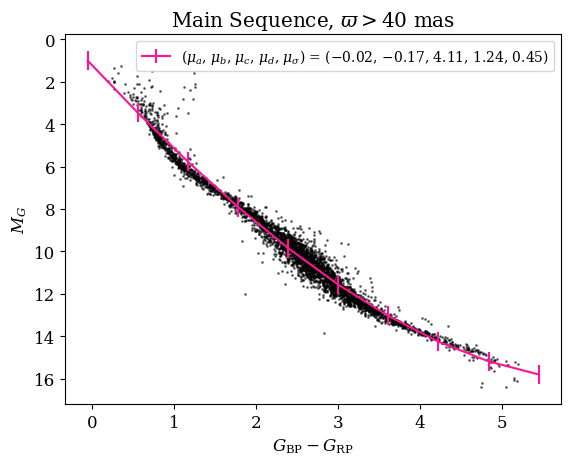

In [30]:
mean_a = jnp.mean(samples['a']).item()
mean_b = jnp.mean(samples['b']).item()
mean_c = jnp.mean(samples['c']).item()
mean_d = jnp.mean(samples['d']).item()
mean_sigma = jnp.mean(samples['σ']).item()

plt.scatter(main_df.bp_rp, main_df.mg, s=1, alpha=0.5, color='k')
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

xlow, xhigh = plt.xlim()
testx = jnp.linspace(xlow, xhigh, 10)
mu = mean_a * testx**3 + mean_b * testx**2 + mean_c * testx + mean_d

plt.errorbar(testx, mu, yerr=mean_sigma, color='deeppink',  
             label=fr'($\mu_a$, $\mu_b$, $\mu_c$, $\mu_d$, $\mu_{{\sigma}}$) = (${round(mean_a,2)}$, ${round(mean_b,2)}$, ${round(mean_c,2)}$, ${round(mean_d,2)}$, ${round(mean_sigma,2)}$)')
    
plt.legend(fontsize='small')
plt.gca().invert_yaxis()
plt.show()

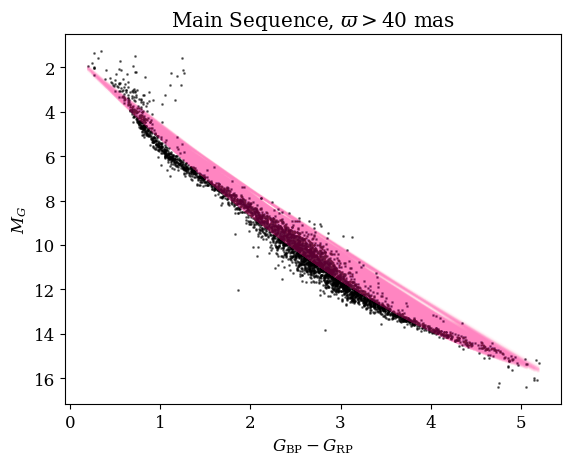

In [31]:
plt.scatter(main_df.bp_rp, main_df.mg, s=1, alpha=0.5, color='k')
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

xlow, xhigh = plt.xlim()
testx = jnp.linspace(xlow, xhigh, 100)

for i in random.choice(rng_key, num_samples, (50,)):
    mu = samples['a'][i] * x**3 + samples['b'][i] * x**2 + samples['c'][i] * x + samples['d'][i]
    plt.plot(x, mu, color='deeppink', alpha=0.01);
    
plt.gca().invert_yaxis()
plt.show()

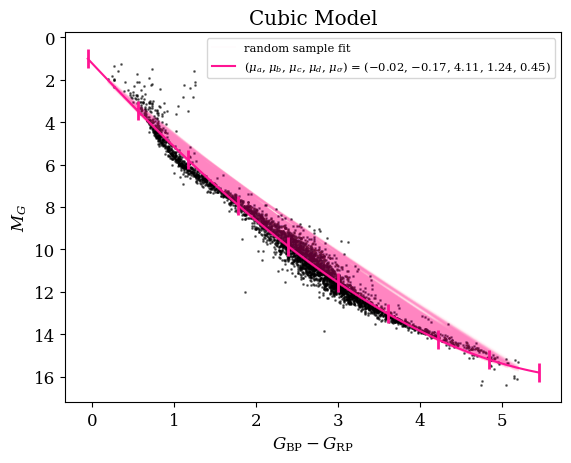

In [32]:
plt.scatter(main_df.bp_rp, main_df.mg, s=1, alpha=0.5, color='k')
plt.title(r'Cubic Model')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

xlow, xhigh = plt.xlim()
testx = jnp.linspace(xlow, xhigh, 100)

label = "random sample fit"
for i in random.choice(rng_key, num_samples, (50,)):
    mu = samples['a'][i] * x**3 + samples['b'][i] * x**2 + samples['c'][i] * x + samples['d'][i]
    plt.plot(x, mu, color='deeppink', alpha=0.01, label=label);
    label = None

mu = mean_a * testx**3 + mean_b * testx**2 + mean_c * testx + mean_d
plt.plot(testx, mu, color='deeppink',
         label=fr'($\mu_a$, $\mu_b$, $\mu_c$, $\mu_d$, $\mu_{{\sigma}}$) = (${round(mean_a,2)}$, ${round(mean_b,2)}$, ${round(mean_c,2)}$, ${round(mean_d,2)}$, ${round(mean_sigma,2)}$)')

testx = jnp.linspace(xlow, xhigh, 10)
mu = mean_a * testx**3 + mean_b * testx**2 + mean_c * testx + mean_d

plt.errorbar(testx, mu, yerr=mean_sigma, color='deeppink', linewidth=0, elinewidth=2) 
    
plt.legend(fontsize='x-small')
plt.gca().invert_yaxis()
plt.show()

### Quartic Model

In [33]:
def quartic_model(x=None, y=None, σ=None):
    # priors
    a = numpyro.sample('a', dist.Normal(scale=100))
    b = numpyro.sample('b', dist.Normal(scale=100))
    c = numpyro.sample('c', dist.Normal(scale=100))
    d = numpyro.sample('d', dist.Normal(scale=100))
    f = numpyro.sample('f', dist.Normal(scale=100))

    σ = numpyro.sample('σ', dist.HalfNormal(scale=5))

    # Define the mean of the normal likelihood
    μ = numpyro.deterministic("μ",  a*x**4 + b*x**3 + c*x**2 + d*x + f)

    # Likelihood (sampling distribution) of observations
    with numpyro.plate("data", len(x)):
        obs = numpyro.sample('y', dist.Normal(loc=μ, scale=σ), obs=y)

In [34]:
# Generate a starting key, which we'll split for later operations.
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)

kernel = infer.NUTS(quartic_model)
num_samples = 5000
mcmc = infer.MCMC(
    kernel,
    num_chains=2,
    num_warmup=1000,
    num_samples=num_samples)
mcmc.run(rng_key_,
         x=x,
         y=y)
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
         a     -0.04      0.00     -0.04     -0.05     -0.04   1183.69      1.00
         b      0.45      0.05      0.45      0.37      0.53   1135.52      1.00
         c     -1.89      0.18     -1.89     -2.17     -1.59   1111.35      1.00
         d      6.56      0.27      6.56      6.11      6.99   1118.30      1.00
         f      0.15      0.13      0.15     -0.07      0.36   1194.93      1.00
         σ      0.44      0.01      0.44      0.43      0.45   3550.03      1.00

Number of divergences: 0


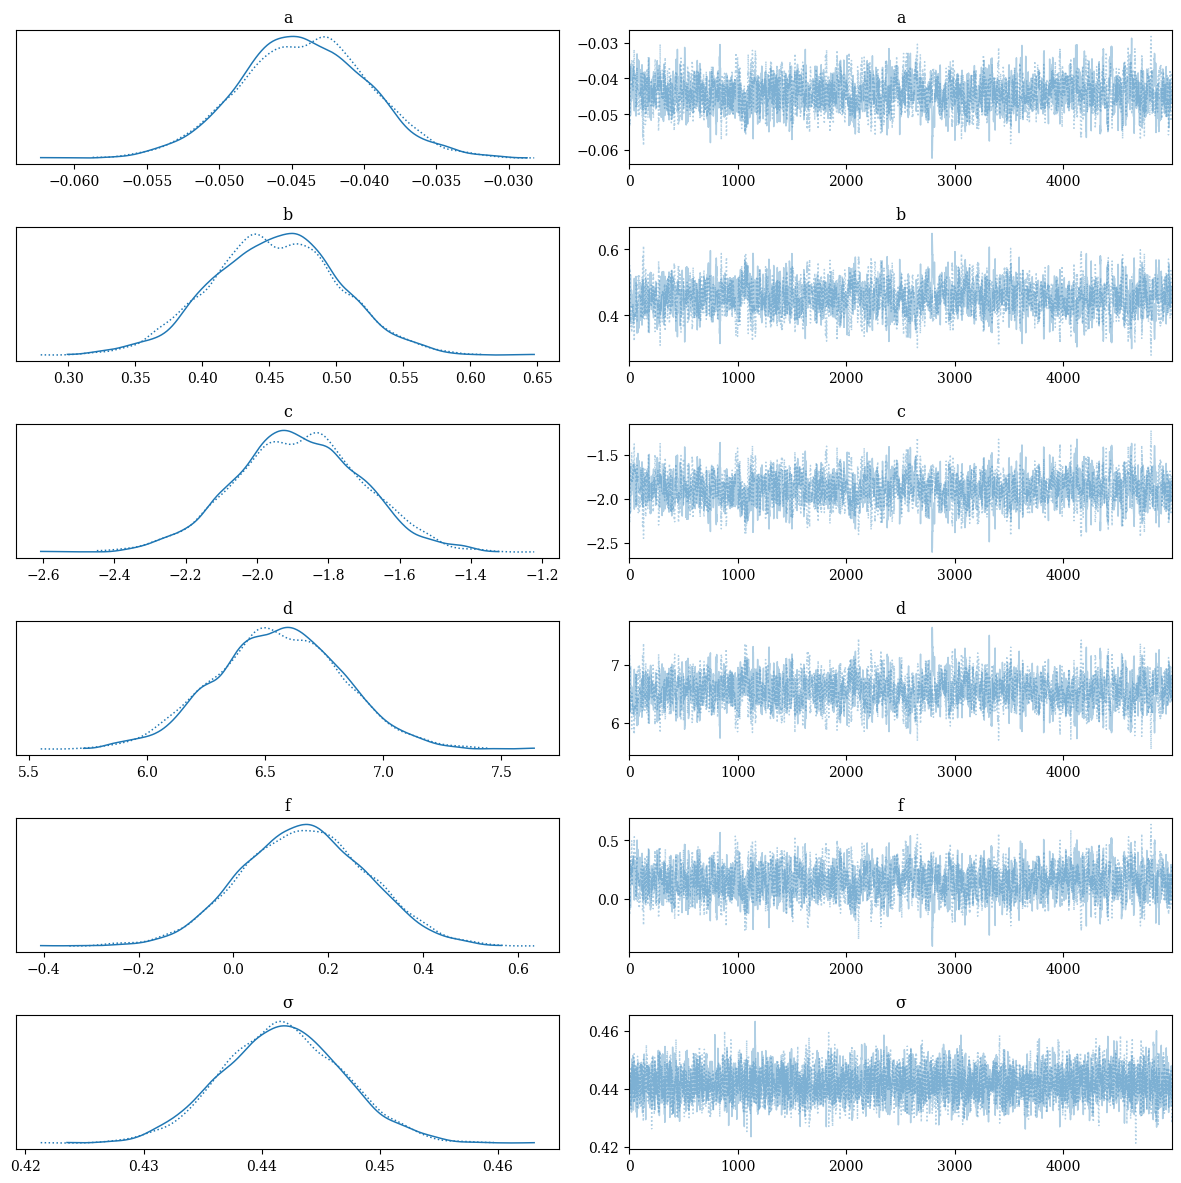

In [35]:
az.plot_trace(mcmc, var_names=["~μ"]);
plt.tight_layout()

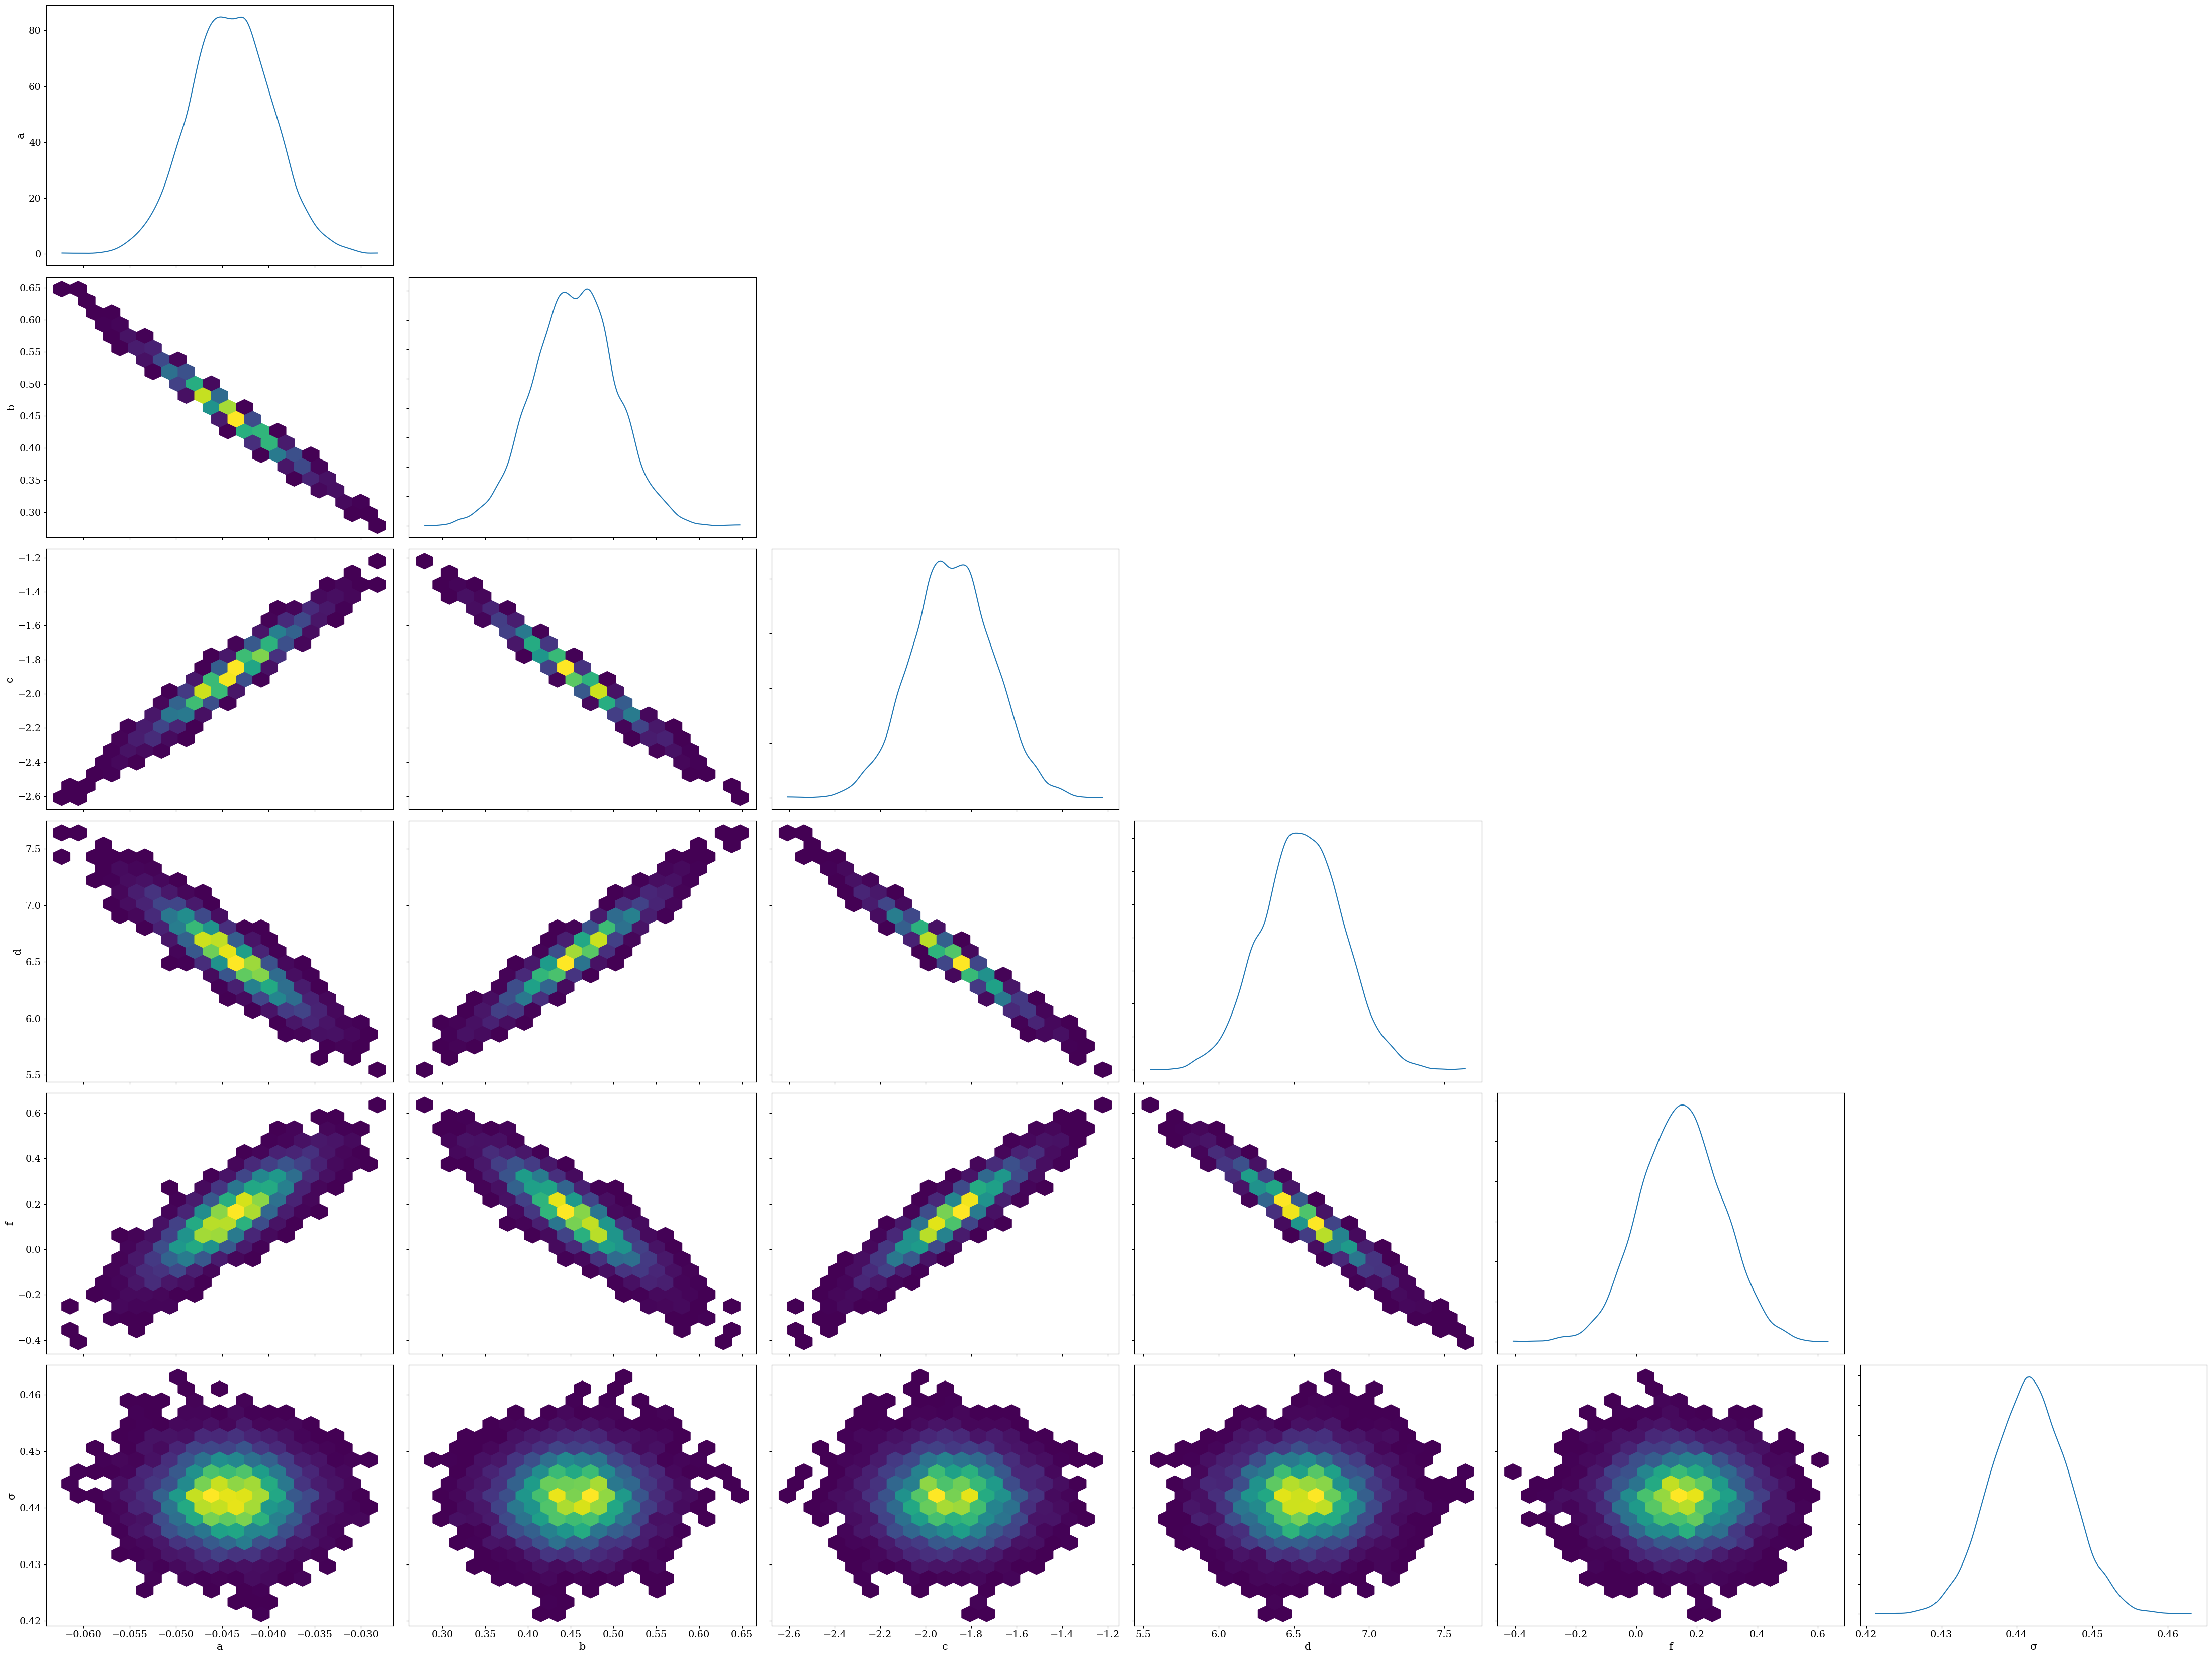

In [36]:
az.plot_pair(mcmc,marginals=True, kind='hexbin', var_names=["~μ"])
plt.tight_layout()
plt.show()

In [37]:
samples = mcmc.get_samples()

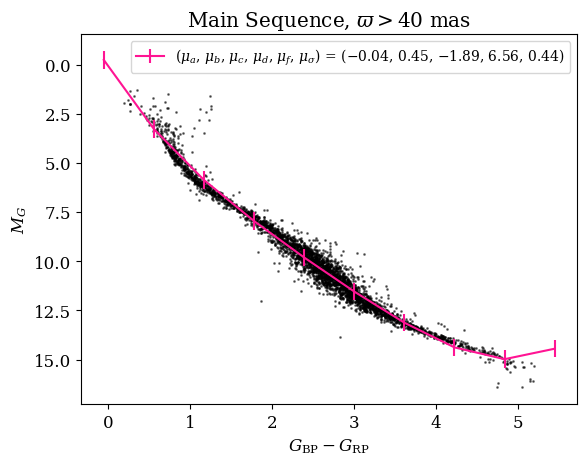

In [38]:
mean_a = jnp.mean(samples['a']).item()
mean_b = jnp.mean(samples['b']).item()
mean_c = jnp.mean(samples['c']).item()
mean_d = jnp.mean(samples['d']).item()
mean_f = jnp.mean(samples['f']).item()
mean_sigma = jnp.mean(samples['σ']).item()

plt.scatter(main_df.bp_rp, main_df.mg, s=1, alpha=0.5, color='k')
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

xlow, xhigh = plt.xlim()
testx = jnp.linspace(xlow, xhigh, 10)
mu = mean_a * testx**4 + mean_b * testx**3 + mean_c * testx**2 + mean_d * testx + mean_f

plt.errorbar(testx, mu, yerr=mean_sigma, color='deeppink',  
             label=fr'($\mu_a$, $\mu_b$, $\mu_c$, $\mu_d$, $\mu_f$, $\mu_{{\sigma}}$) = (${round(mean_a,2)}$, ${round(mean_b,2)}$, ${round(mean_c,2)}$, ${round(mean_d,2)}$, ${round(mean_sigma,2)}$)')
    
plt.legend(fontsize='small')
plt.gca().invert_yaxis()
plt.show()

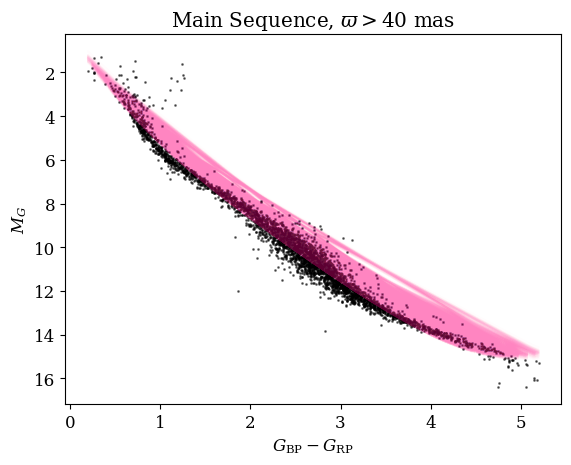

In [39]:
plt.scatter(main_df.bp_rp, main_df.mg, s=1, alpha=0.5, color='k')
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

xlow, xhigh = plt.xlim()
testx = jnp.linspace(xlow, xhigh, 100)

for i in random.choice(rng_key, num_samples, (50,)):
    mu = samples['a'][i] * x**4 + samples['b'][i] * x**3 + samples['c'][i] * x**2 + samples['d'][i] * x + samples['f'][i]
    plt.plot(x, mu, color='deeppink', alpha=0.01);
    
plt.gca().invert_yaxis()
plt.show()

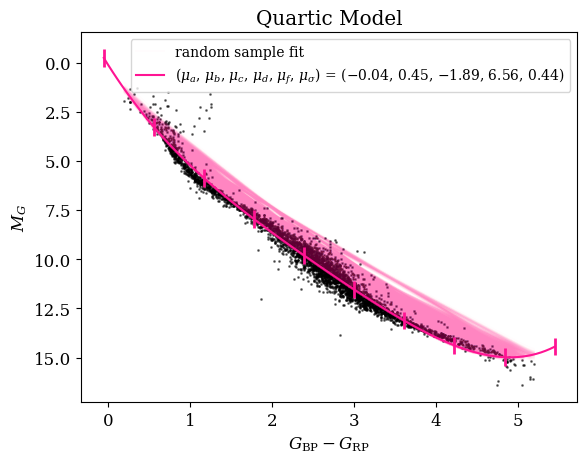

In [40]:
plt.scatter(main_df.bp_rp, main_df.mg, s=1, alpha=0.5, color='k')
plt.title(r'Quartic Model')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

xlow, xhigh = plt.xlim()
testx = jnp.linspace(xlow, xhigh, 100)

label = "random sample fit"
for i in random.choice(rng_key, num_samples, (50,)):
    mu = samples['a'][i] * x**4 + samples['b'][i] * x**3 + samples['c'][i] * x**2 + samples['d'][i] * x + samples['f'][i]
    plt.plot(x, mu, color='deeppink', alpha=0.01, label=label);
    label = None
    
mu = mean_a * testx**4 + mean_b * testx**3 + mean_c * testx**2 + mean_d * testx + mean_f
plt.plot(testx, mu, color='deeppink',
         label=fr'($\mu_a$, $\mu_b$, $\mu_c$, $\mu_d$, $\mu_f$, $\mu_{{\sigma}}$) = (${round(mean_a,2)}$, ${round(mean_b,2)}$, ${round(mean_c,2)}$, ${round(mean_d,2)}$, ${round(mean_sigma,2)}$)')

testx = jnp.linspace(xlow, xhigh, 10)
mu = mean_a * testx**4 + mean_b * testx**3 + mean_c * testx**2 + mean_d * testx + mean_f

plt.errorbar(testx, mu, yerr=mean_sigma, color='deeppink', linewidth=0, elinewidth=2)
    
plt.legend(fontsize='small')
plt.gca().invert_yaxis()
plt.show()

# Part II

Now let's bring the white dwarfs back into the mix, focusing on all the objects with parallax > 40 milliarcseconds.

1. Construct a mixture model with `NumPyro` that simultaneously describes the main sequence stars and white dwarfs, each described by a linear relationship with its own slope, y-intercept, and scatter of observations about it.

    **Tips:**
    1. Recall our outlier model we built, which outlines the machinery for building a mixture model that allows for our data to be described by more than one distribution.
    1. Our model will now be composed of two lines.  If we impose the same priors for the parameters of each line, then the two lines will be degenerate and sampling gets unnecessarily tricky.  There are many ways we could avoid this degeneracy, but for now I suggest imposing unique priors on the y-intercepts.  I also recommend a relatively narrow prior on the slopes of the lines to get the model from trying crazy solutions:
        ```python
        m_ms = numpyro.sample('m_ms', dist.Uniform(2, 5))
        b_ms = numpyro.sample('b_ms', dist.Uniform(0, 5))

        m_wd = numpyro.sample('m_wd', dist.Uniform(2, 5))
        b_wd = numpyro.sample('b_wd', dist.Uniform(10, 15))
        ```
2. Plot the two lines for each of 50 randomly chosen posterior samples from your MCMC.  Discuss the quality of the fits, and in particular the constraints.  Is the model able to identify the two populations?

3. **Graduate students:**
    A. Plot a distribution of the probabilities that each star in our catalog is on the main sequence.  Are there any stars which aren't confidently associated with a particular population?
    B. Relax the priors on slope and y-intercept and run an MCMC:
    ```python
    m_ms = numpyro.sample('m_ms', dist.Normal(scale=10))
    b_ms = numpyro.sample('b_ms', dist.Normal(scale=20))

    m_wd = numpyro.sample('m_wd', dist.Normal(scale=10))
    b_wd = numpyro.sample('b_wd', dist.Normal(scale=20))
    ```
    Take a look at the trace plots and the fits to the data.  Can you describe what's happening?

## Problem 1

In [9]:
x = jnp.array(nearby_df['bp_rp'])
y = jnp.array(nearby_df['mg'])

In [11]:
def double_linear_model(x=None, y=None, σ=None):
    # First let's construct our foreground (i.e., linear) model
    m_ms = numpyro.sample('m_ms', dist.Uniform(2, 5))
    b_ms = numpyro.sample('b_ms', dist.Uniform(0, 5))
    μ_ms = m_ms * x + b_ms
    σ = numpyro.sample('σ', dist.HalfNormal(scale=5))
    dist_ms = dist.Normal(μ_ms, σ)

    # Now lets define a model for the background (i.e., outliers)
    m_wd = numpyro.sample('m_wd', dist.Uniform(2, 5))
    b_wd = numpyro.sample('b_wd', dist.Uniform(10, 15))
    μ_wd = m_wd * x + b_wd
    dist_wd = dist.Normal(μ_wd, σ)

    # We're going to assign each observation probabilistically to ms or wd using Categorical parameters
    P_ms = numpyro.sample('P_ms', dist.Uniform(0, 1)) # Prob an observation will be in the main sequence

    # Define the foreground/background parameters, with equal probability between categories
    mixing_dist = dist.Categorical(probs=jnp.array([P_ms, 1 - P_ms]))
    mixture = dist.MixtureGeneral(mixing_dist, [dist_ms, dist_wd])

    # Likelihood
    with numpyro.plate("data", len(x)):
        y_ = numpyro.sample("obs", mixture, obs=y)

        # Until here, where we can track the membership probability of each sample
        log_probs = mixture.component_log_probs(y_)
        numpyro.deterministic(
            "log_p_ms", log_probs - jax.nn.logsumexp(log_probs, axis=-1, keepdims=True)
        )

In [13]:
# Generate a starting key, which we'll split for later operations.
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)

kernel = infer.NUTS(double_linear_model)
num_samples = 5000
mcmc = infer.MCMC(
    kernel,
    num_chains=2,
    num_warmup=1000,
    num_samples=num_samples)
mcmc.run(rng_key_,
         x=x,
         y=y)
mcmc.print_summary()

  0%|          | 0/6000 [00:00<?, ?it/s]

  0%|          | 0/6000 [00:00<?, ?it/s]


                mean       std    median      5.0%     95.0%     n_eff     r_hat
      P_ms      0.94      0.00      0.94      0.93      0.94   9013.30      1.00
      b_ms      2.58      0.03      2.58      2.54      2.63   5985.12      1.00
      b_wd     12.18      0.06     12.18     12.08     12.27   6304.08      1.00
      m_ms      2.94      0.01      2.94      2.92      2.95   6022.59      1.00
      m_wd      2.50      0.08      2.50      2.37      2.62   6446.60      1.00
         σ      0.56      0.01      0.56      0.55      0.57   9163.89      1.00

Number of divergences: 0


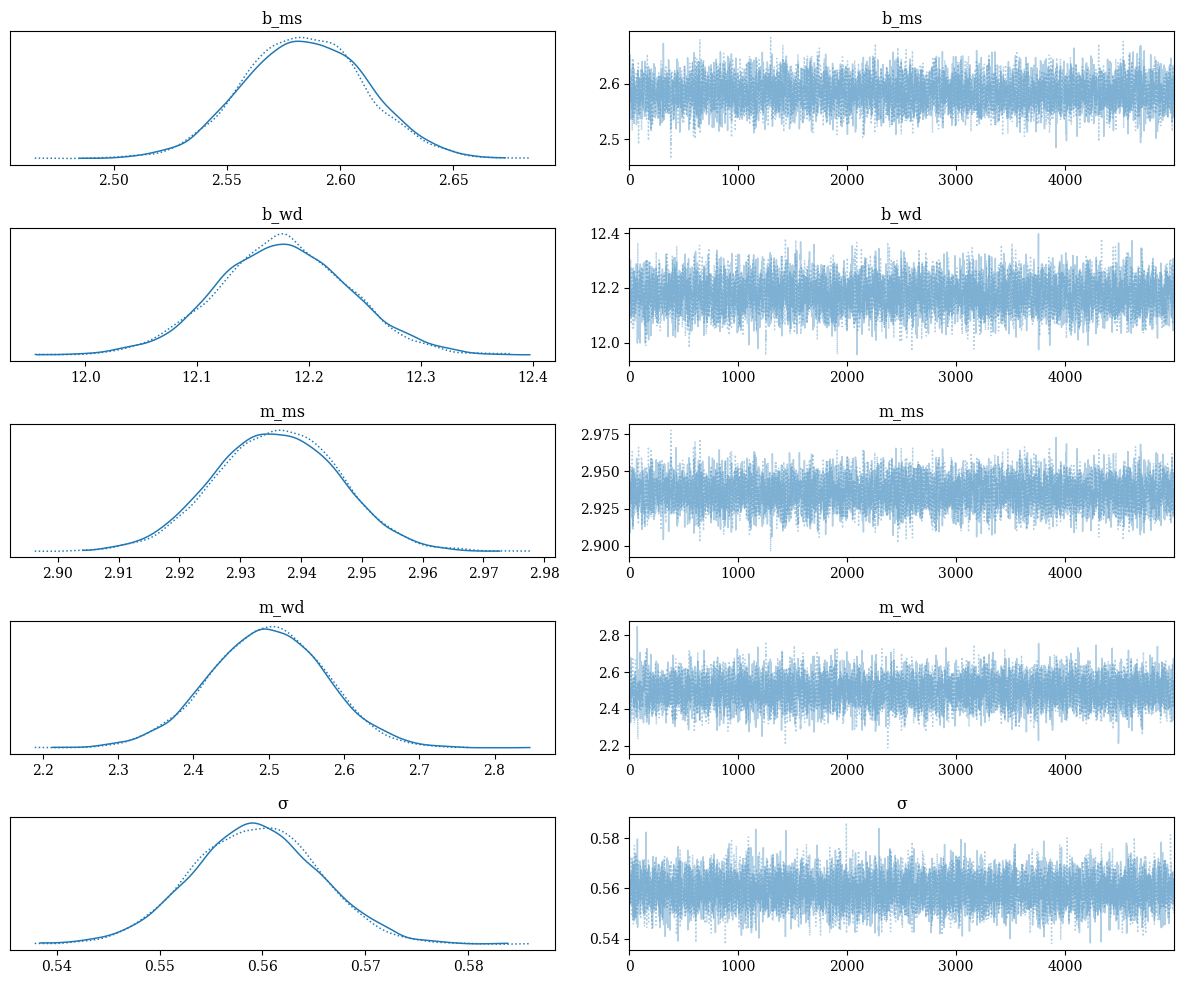

In [14]:
az.plot_trace(mcmc, var_names=["b_ms","b_wd","m_ms","m_wd","σ"]);
plt.tight_layout()
plt.show()

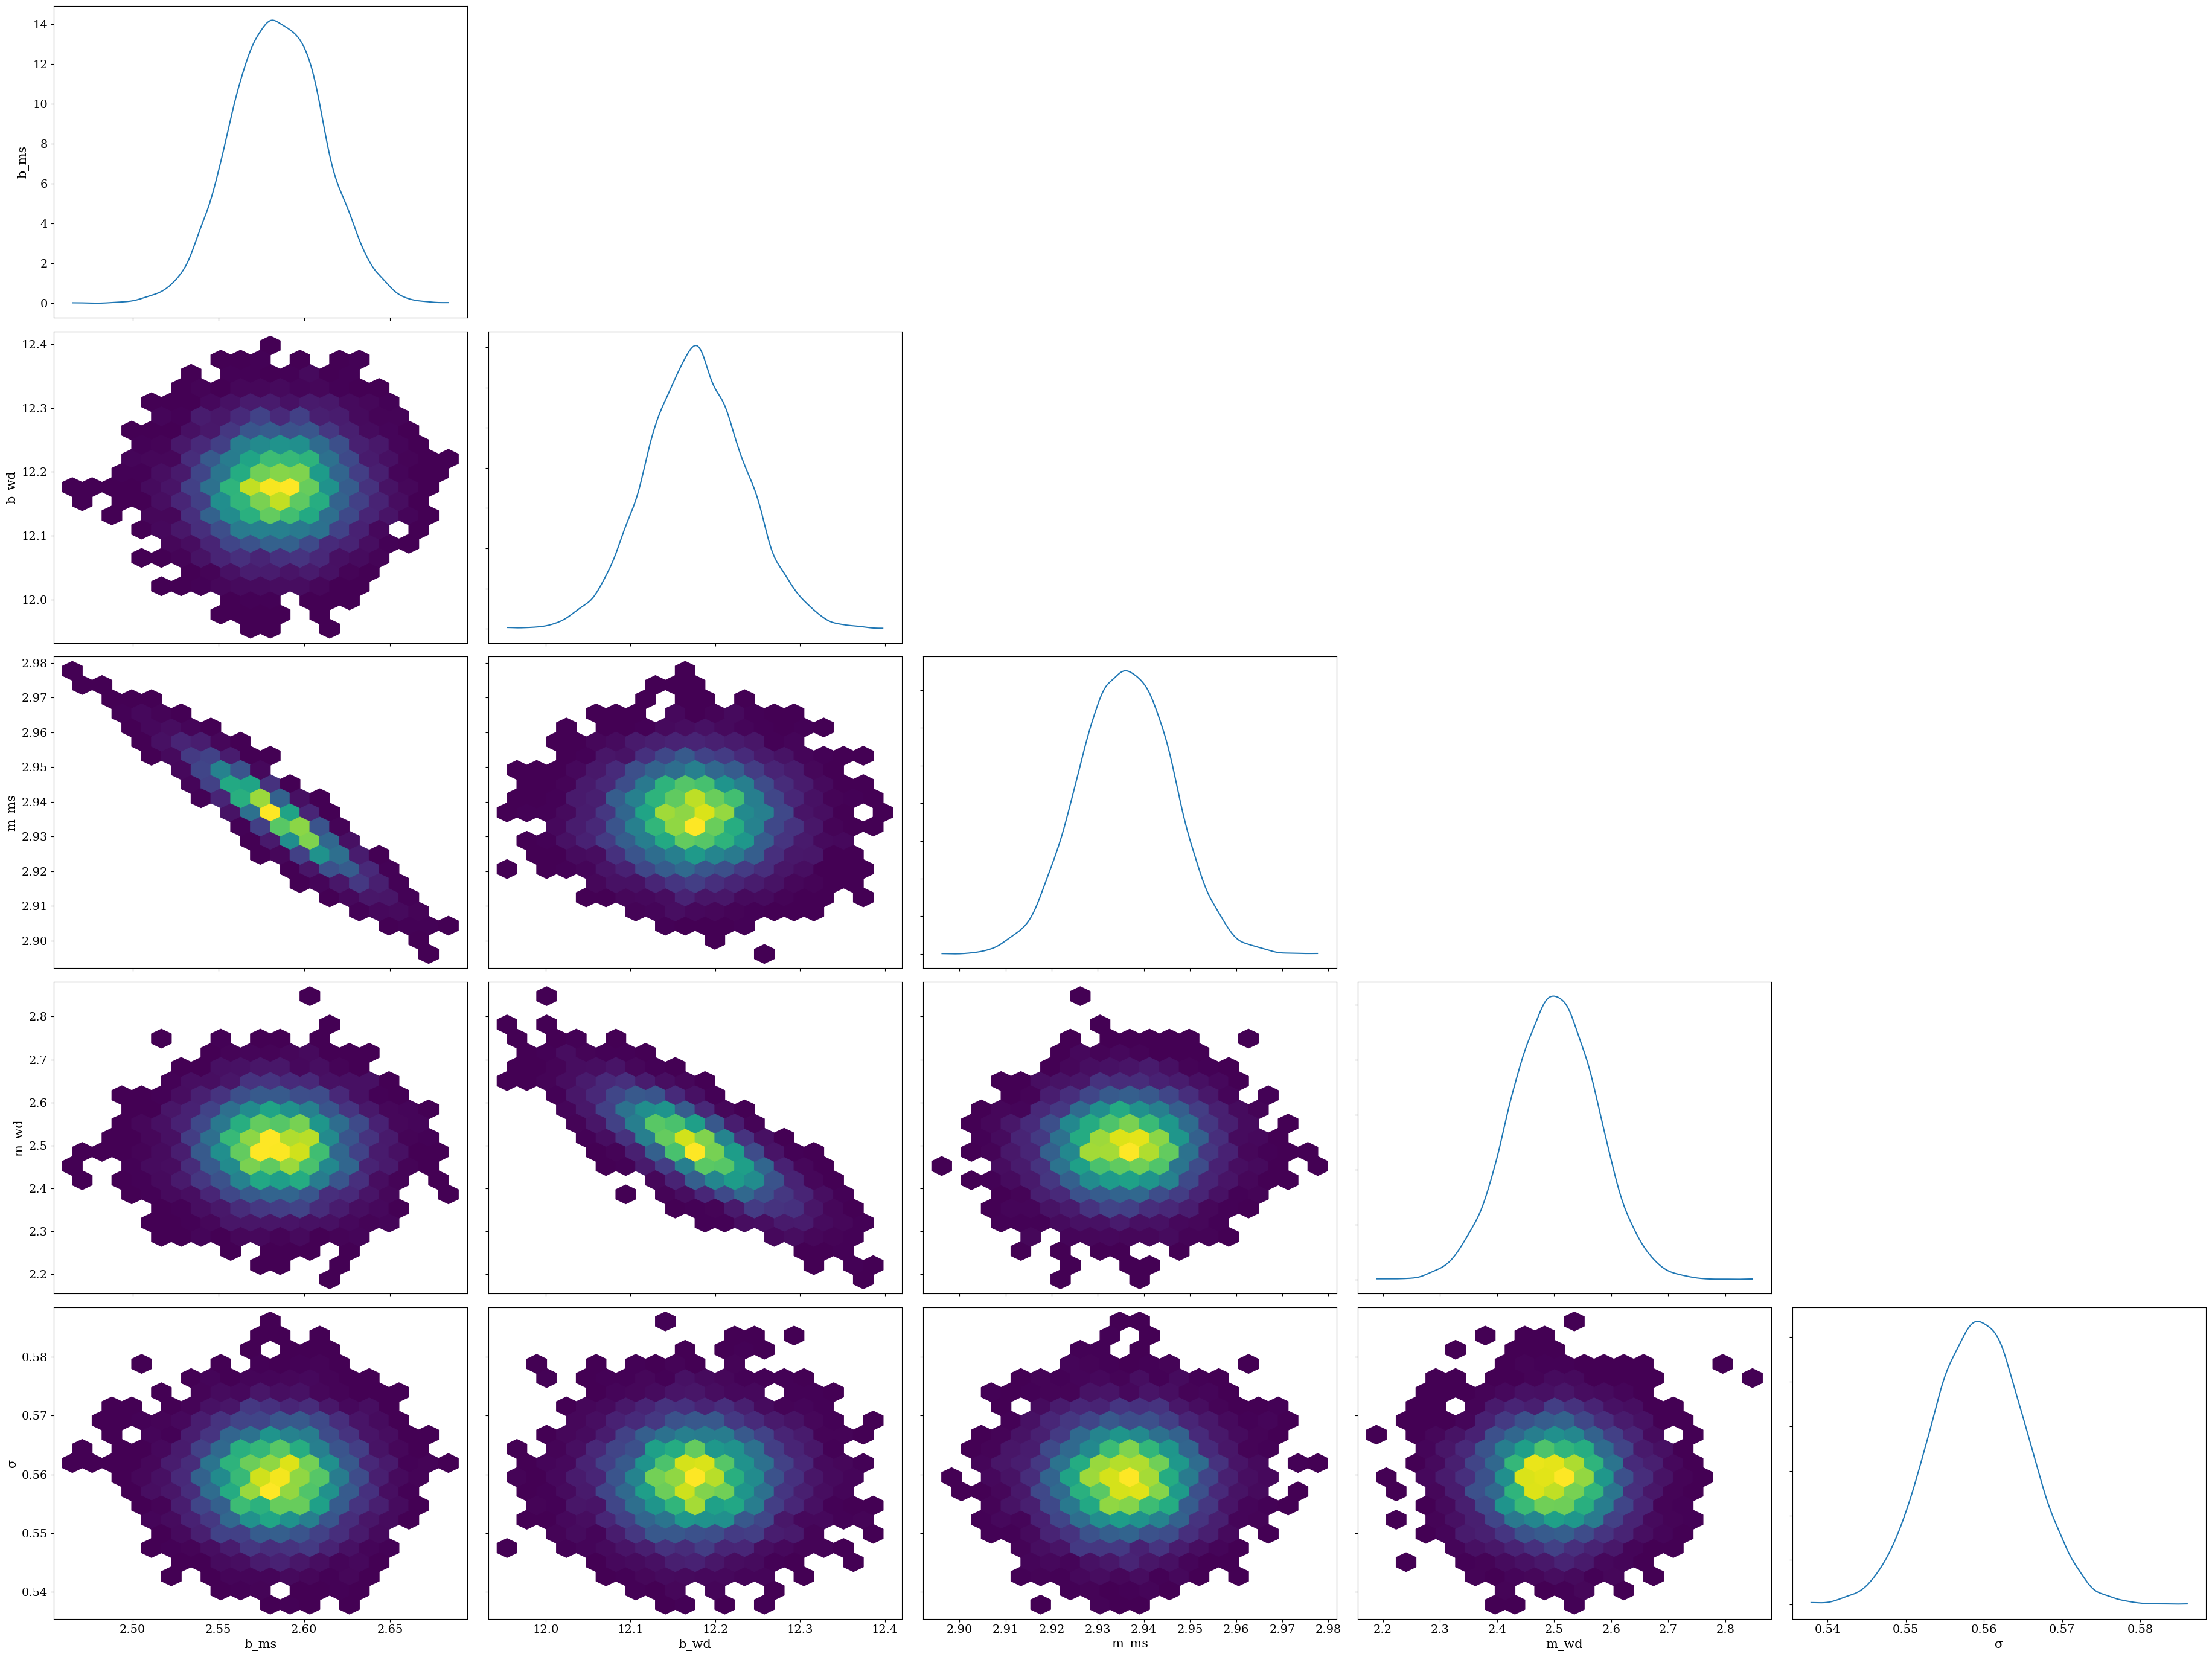

In [15]:
az.plot_pair(mcmc, var_names=["b_ms","b_wd","m_ms","m_wd","σ"], marginals=True, kind='hexbin')
plt.tight_layout()
plt.show()

In [16]:
samples = mcmc.get_samples()

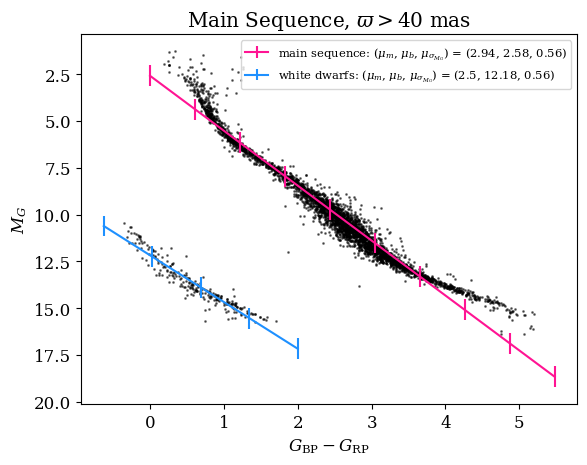

In [17]:
mean_m_ms = jnp.mean(samples['m_ms']).item()
mean_b_ms = jnp.mean(samples['b_ms']).item()
mean_m_wd = jnp.mean(samples['m_wd']).item()
mean_b_wd = jnp.mean(samples['b_wd']).item()
mean_sigmg = jnp.mean(samples['σ']).item()

plt.scatter(nearby_df.bp_rp, nearby_df.mg, s=1, alpha=0.5, color='k')
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

xlow, xhigh = plt.xlim()
testx_ms = jnp.linspace(0, xhigh, 10)
testx_wd = jnp.linspace(xlow, 2, 5)
mu_ms = mean_m_ms * testx_ms + mean_b_ms
mu_wd = mean_m_wd * testx_wd + mean_b_wd

plt.errorbar(testx_ms, mu_ms, yerr=mean_sigmg, color='deeppink',  
             label=fr'main sequence: ($\mu_m$, $\mu_b$, $\mu_{{\sigma_{{M_G}}}}$) = (${round(mean_m_ms,2)}$, ${round(mean_b_ms,2)}$, ${round(mean_sigmg,2)}$)')
plt.errorbar(testx_wd, mu_wd, yerr=mean_sigmg, color='dodgerblue',  
             label=fr'white dwarfs: ($\mu_m$, $\mu_b$, $\mu_{{\sigma_{{M_G}}}}$) = (${round(mean_m_wd,2)}$, ${round(mean_b_wd,2)}$, ${round(mean_sigmg,2)}$)')
    
plt.legend(fontsize='x-small', loc='upper right')
plt.gca().invert_yaxis()
plt.show()

## Problem 2

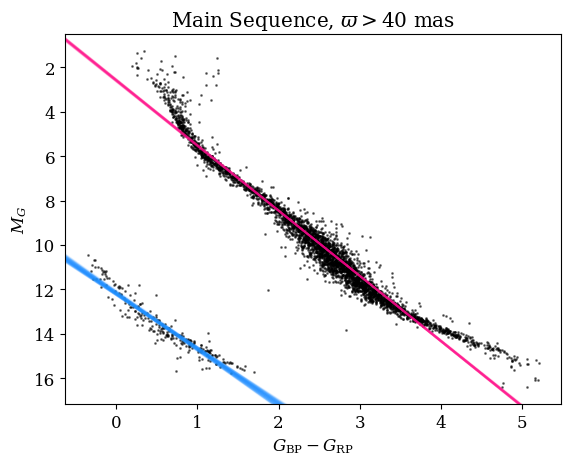

In [17]:
plt.scatter(nearby_df.bp_rp, nearby_df.mg, s=1, alpha=0.5, color='k')
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

xlow, xhigh = plt.xlim()
testx = jnp.linspace(xlow, xhigh, 100)

for i in random.choice(rng_key, num_samples, (50,)):
    mu_ms = samples['m_ms'][i] * testx + samples['b_ms'][i]
    plt.plot(testx, mu_ms, color='deeppink', alpha=0.05);
    
    mu_wd = samples['m_wd'][i] * testx + samples['b_wd'][i]
    plt.plot(testx, mu_wd, color='dodgerblue', alpha=0.1);
    
plt.gca().invert_yaxis()
plt.ylim(ylow,yhigh)
plt.xlim(xlow,xhigh)
plt.show()

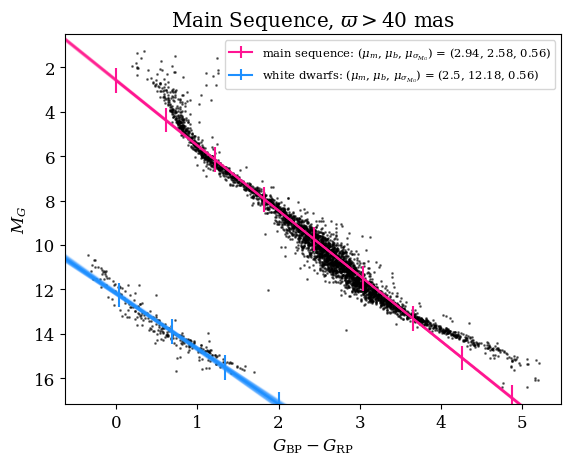

In [18]:
plt.scatter(nearby_df.bp_rp, nearby_df.mg, s=1, alpha=0.5, color='k')
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

xlow, xhigh = plt.xlim()
testx = jnp.linspace(xlow, xhigh, 100)

for i in random.choice(rng_key, num_samples, (50,)):
    mu_ms = samples['m_ms'][i] * testx + samples['b_ms'][i]
    plt.plot(testx, mu_ms, color='deeppink', alpha=0.05);
    
    mu_wd = samples['m_wd'][i] * testx + samples['b_wd'][i]
    plt.plot(testx, mu_wd, color='dodgerblue', alpha=0.1);
    
testx_ms = jnp.linspace(0, xhigh, 10)
testx_wd = jnp.linspace(xlow, 2, 5)
mu_ms = mean_m_ms * testx_ms + mean_b_ms
mu_wd = mean_m_wd * testx_wd + mean_b_wd

plt.errorbar(testx_ms, mu_ms, yerr=mean_sigmg, color='deeppink',  
             label=fr'main sequence: ($\mu_m$, $\mu_b$, $\mu_{{\sigma_{{M_G}}}}$) = (${round(mean_m_ms,2)}$, ${round(mean_b_ms,2)}$, ${round(mean_sigmg,2)}$)')
plt.errorbar(testx_wd, mu_wd, yerr=mean_sigmg, color='dodgerblue',  
             label=fr'white dwarfs: ($\mu_m$, $\mu_b$, $\mu_{{\sigma_{{M_G}}}}$) = (${round(mean_m_wd,2)}$, ${round(mean_b_wd,2)}$, ${round(mean_sigmg,2)}$)')
    
plt.legend(fontsize='x-small', loc='upper right')
plt.gca().invert_yaxis()
plt.ylim(ylow,yhigh)
plt.xlim(xlow,xhigh)
plt.show()

## Problem 3

In [20]:
p_ms = jnp.mean(jnp.exp(samples["log_p_ms"][..., 0]), axis=0)
σ_p_ms = jnp.std(jnp.exp(samples["log_p_ms"][..., 0]), axis=0)

p_ms.shape

(4070,)

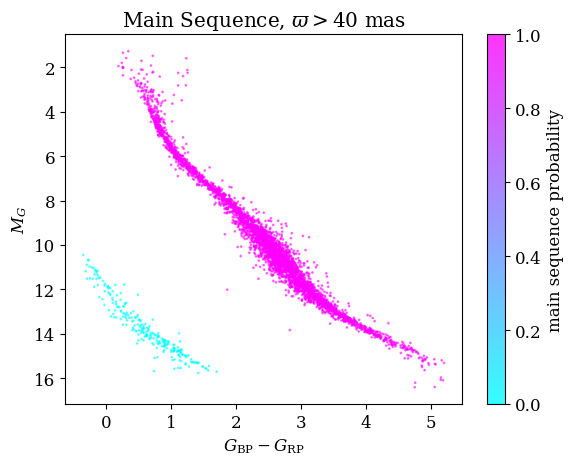

In [21]:
sc = plt.scatter(nearby_df.bp_rp, nearby_df.mg, c=p_ms, s=1, cmap="cool", alpha=0.8)
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

plt.colorbar(label="main sequence probability");
sc.set_alpha(0.5)

plt.gca().invert_yaxis()
plt.ylim(ylow,yhigh)
plt.xlim(xlow,xhigh)
plt.show()

In [10]:
def double_linear_relaxed(x=None, y=None, σ=None):
    # First let's construct our foreground (i.e., linear) model
    m_ms = numpyro.sample('m_ms', dist.Normal(scale=10))
    b_ms = numpyro.sample('b_ms', dist.Normal(scale=20))
    μ_ms = m_ms * x + b_ms
    σ = numpyro.sample('σ', dist.HalfNormal(scale=5))
    dist_ms = dist.Normal(μ_ms, σ)

    # Now lets define a model for the background (i.e., outliers)
    m_wd = numpyro.sample('m_wd', dist.Normal(scale=10))
    b_wd = numpyro.sample('b_wd', dist.Normal(scale=20))
    μ_wd = m_wd * x + b_wd
    dist_wd = dist.Normal(μ_wd, σ)

    # We're going to assign each observation probabilistically to ms or wd using Categorical parameters
    P_ms = numpyro.sample('P_ms', dist.Uniform(0, 1)) # Prob an observation will be in the main sequence

    # Define the foreground/background parameters, with equal probability between categories
    mixing_dist = dist.Categorical(probs=jnp.array([P_ms, 1 - P_ms]))
    mixture = dist.MixtureGeneral(mixing_dist, [dist_ms, dist_wd])

    # Likelihood
    with numpyro.plate("data", len(x)):
        y_ = numpyro.sample("obs", mixture, obs=y)

        # Until here, where we can track the membership probability of each sample
        log_probs = mixture.component_log_probs(y_)
        numpyro.deterministic(
            "log_p_ms", log_probs - jax.nn.logsumexp(log_probs, axis=-1, keepdims=True)
        )

In [11]:
# Generate a starting key, which we'll split for later operations.
rng_key = random.PRNGKey(0)
rng_key, rng_key_ = random.split(rng_key)

kernel = infer.NUTS(double_linear_relaxed)
num_samples = 5000
mcmc = infer.MCMC(
    kernel,
    num_chains=2,
    num_warmup=1000,
    num_samples=num_samples)
mcmc.run(rng_key_,
         x=x,
         y=y)
mcmc.print_summary()

/tmp/ipykernel_5389/1569439566.py:7: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = infer.MCMC(
sample: 100%|██████████| 6000/6000 [00:58<00:00, 102.19it/s, 15 steps of size 2.31e-01. acc. prob=0.93]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
      P_ms      0.50      0.44      0.50      0.06      0.94      1.00    136.78
      b_ms      7.38      4.79      7.30      2.54     12.23      1.00    121.38
      b_wd      7.38      4.80      7.32      2.54     12.24      1.00    121.60
      m_ms      2.72      0.22      2.85      2.43      2.96      1.03      4.75
      m_wd      2.72      0.23      2.84      2.43      2.96      1.03      4.78
         σ      0.56      0.01      0.56      0.55      0.57   8766.12      1.00

Number of divergences: 0


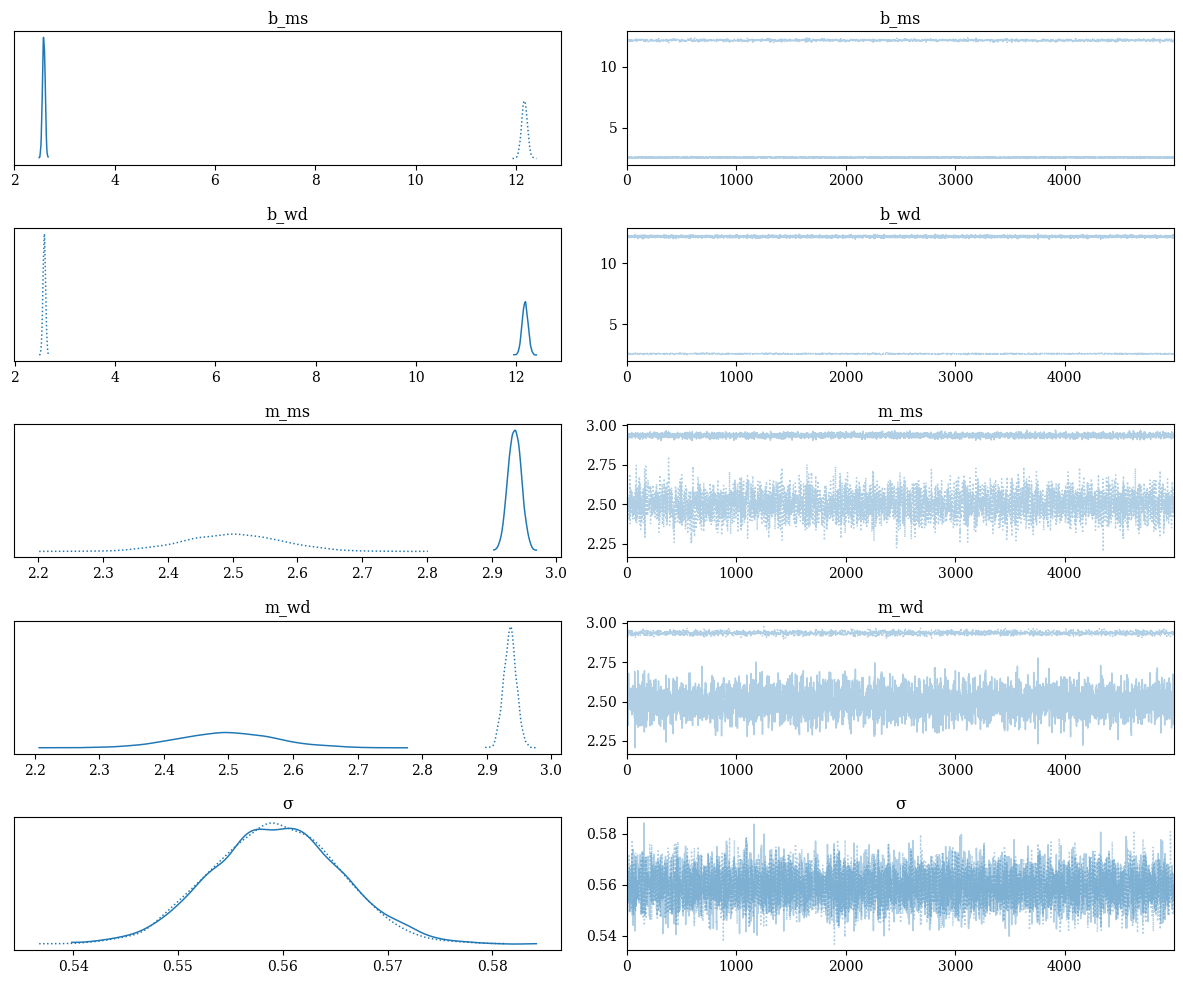

In [12]:
az.plot_trace(mcmc, var_names=["b_ms","b_wd","m_ms","m_wd","σ"]);
plt.tight_layout()
plt.show()

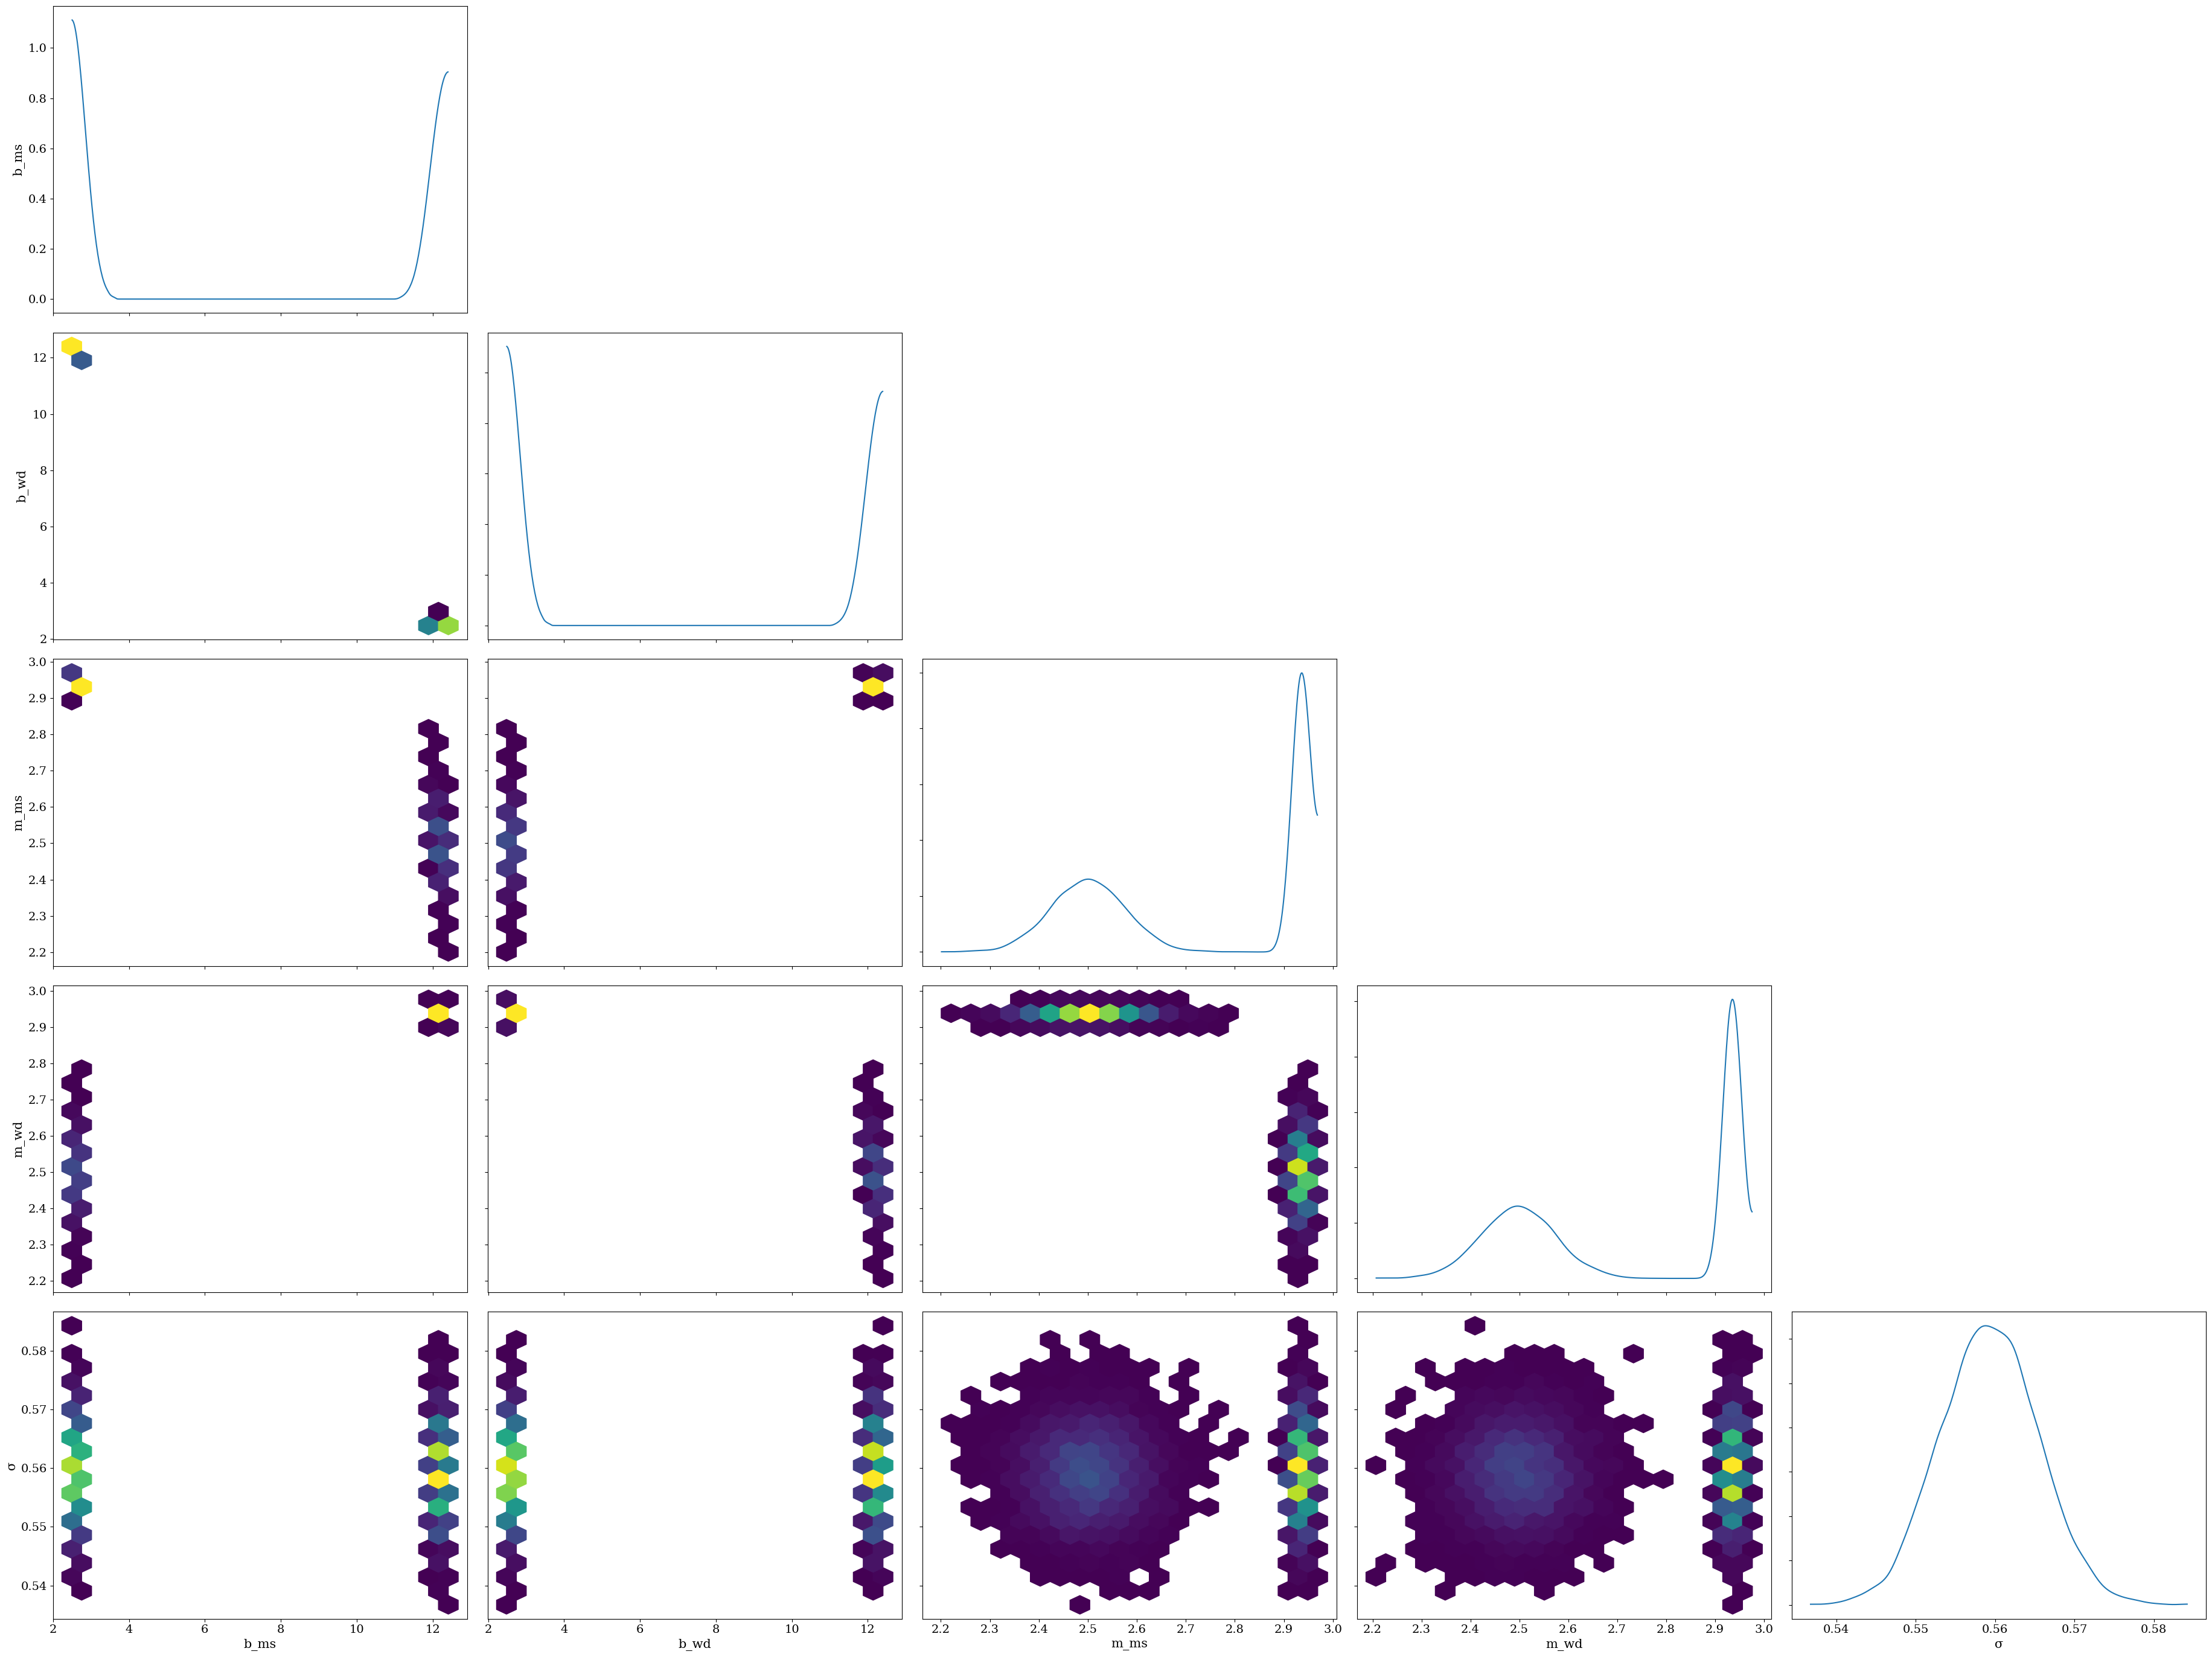

In [13]:
az.plot_pair(mcmc, var_names=["b_ms","b_wd","m_ms","m_wd","σ"], marginals=True, kind='hexbin')
plt.tight_layout()
plt.show()

In [14]:
samples = mcmc.get_samples()

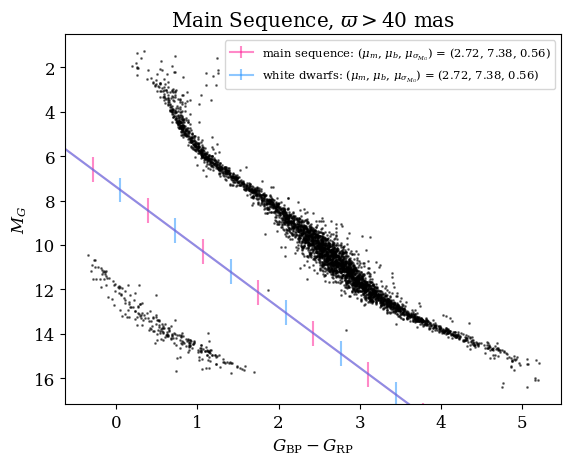

In [15]:
mean_m_ms = jnp.mean(samples['m_ms']).item()
mean_b_ms = jnp.mean(samples['b_ms']).item()
mean_m_wd = jnp.mean(samples['m_wd']).item()
mean_b_wd = jnp.mean(samples['b_wd']).item()
mean_sigmg = jnp.mean(samples['σ']).item()

plt.scatter(nearby_df.bp_rp, nearby_df.mg, s=1, alpha=0.5, color='k')
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

xlow, xhigh = plt.xlim()
x_offset = (xhigh - xlow) / 18
testx_ms = jnp.linspace(xlow-x_offset, xhigh-x_offset, 10)
testx_wd = jnp.linspace(xlow, xhigh, 10)
mu_ms = mean_m_ms * testx_ms + mean_b_ms
mu_wd = mean_m_wd * testx_wd + mean_b_wd

plt.errorbar(testx_ms, mu_ms, yerr=mean_sigmg, color='deeppink', alpha=0.5,
             label=fr'main sequence: ($\mu_m$, $\mu_b$, $\mu_{{\sigma_{{M_G}}}}$) = (${round(mean_m_ms,2)}$, ${round(mean_b_ms,2)}$, ${round(mean_sigmg,2)}$)')
plt.errorbar(testx_wd, mu_wd, yerr=mean_sigmg, color='dodgerblue', alpha=0.5,
             label=fr'white dwarfs: ($\mu_m$, $\mu_b$, $\mu_{{\sigma_{{M_G}}}}$) = (${round(mean_m_wd,2)}$, ${round(mean_b_wd,2)}$, ${round(mean_sigmg,2)}$)')
    
plt.legend(fontsize='x-small', loc='upper right')
plt.gca().invert_yaxis()
plt.ylim(ylow,yhigh)
plt.xlim(xlow,xhigh)
plt.show()

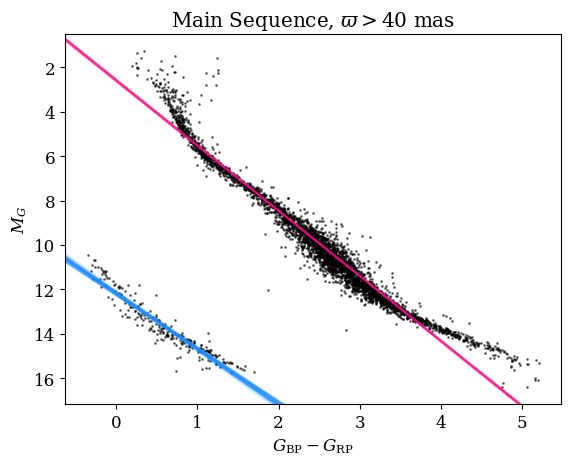

In [16]:
plt.scatter(nearby_df.bp_rp, nearby_df.mg, s=1, alpha=0.5, color='k')
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

xlow, xhigh = plt.xlim()
testx = jnp.linspace(xlow, xhigh, 100)

for i in random.choice(rng_key, num_samples, (50,)):
    mu_ms = samples['m_ms'][i] * testx + samples['b_ms'][i]
    plt.plot(testx, mu_ms, color='deeppink', alpha=0.05);
    
    mu_wd = samples['m_wd'][i] * testx + samples['b_wd'][i]
    plt.plot(testx, mu_wd, color='dodgerblue', alpha=0.1);
    
plt.gca().invert_yaxis()
plt.ylim(ylow,yhigh)
plt.xlim(xlow,xhigh)
plt.show()

In [17]:
p_ms = jnp.mean(jnp.exp(samples["log_p_ms"][..., 0]), axis=0)
σ_p_ms = jnp.std(jnp.exp(samples["log_p_ms"][..., 0]), axis=0)

p_ms.shape

(4070,)

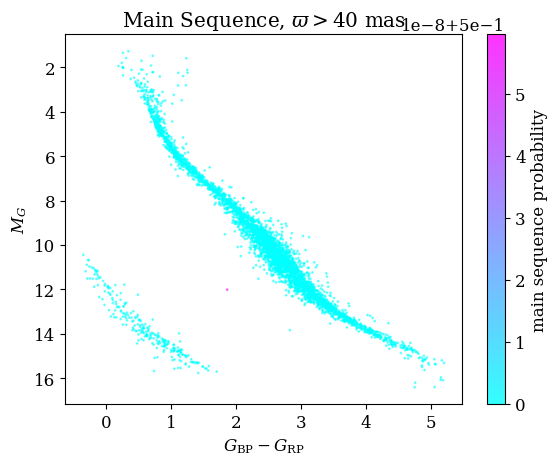

In [18]:
sc = plt.scatter(nearby_df.bp_rp, nearby_df.mg, c=p_ms, s=1, cmap="cool", alpha=0.8)
plt.title(r'Main Sequence, $\varpi > 40$ mas')
plt.xlabel(r"$G_\mathrm{BP} - G_\mathrm{RP}$")
plt.ylabel(r"$M_G$")

plt.colorbar(label="main sequence probability");
sc.set_alpha(0.5)

plt.gca().invert_yaxis()
plt.ylim(ylow,yhigh)
plt.xlim(xlow,xhigh)
plt.show()